# **Section 1: ENVIRONMENT SETUP**

In [1]:
# ============================================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================================

print("🚀 Starting VLSI Defect Detection with Balanced Dataset...")

# Install required packages
!pip install ultralytics torch torchvision opencv-python numpy matplotlib h5py tqdm PyYAML Pillow

# Imports
import os
import random
import shutil
from pathlib import Path
from datetime import datetime
import json
import numpy as np
import cv2
import h5py
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from ultralytics import YOLO
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


🚀 Starting VLSI Defect Detection with Balanced Dataset...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.2 GB


# **Section 2: CONFIGURATION**

In [2]:
# ============================================================================
# SECTION 2: CONFIGURATION
# ============================================================================

class BalancedConfig:
    """Enhanced configuration for balanced VLSI defect detection"""

    # Paths - UPDATE THESE TO YOUR PATHS
    BASE_DIR = '/content/drive/MyDrive/Sadnah'
    DATA_DIR = f'{BASE_DIR}/data'
    OUTPUT_DIR = f'{BASE_DIR}/balanced_yolo_dataset'
    RESULTS_DIR = f'{BASE_DIR}/balanced_results'

    # Dataset parameters - INCREASED SAMPLES
    DEFECTIVE_TARGET_SAMPLES = 40000    # Increased from 10k
    DEFECT_FREE_TARGET_SAMPLES = 30000  # 3:4 ratio (75% of defective)

    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.2
    TEST_SPLIT = 0.1

    # Model parameters
    MODEL_NAME = 'yolov8s.pt'  # Using small for better accuracy
    INPUT_SIZE = 640  # Increased for better detection

    # Training parameters - OPTIMIZED FOR BALANCED DATASET
    EPOCHS = 40      # Increased epochs due to larger dataset
    BATCH_SIZE = 16  # Adjusted for larger input size
    LEARNING_RATE = 0.01
    PATIENCE = 10

    @classmethod
    def create_directories(cls):
        """Create necessary directories"""
        dirs = [
            cls.OUTPUT_DIR,
            cls.RESULTS_DIR,
            f'{cls.OUTPUT_DIR}/train/images',
            f'{cls.OUTPUT_DIR}/train/labels',
            f'{cls.OUTPUT_DIR}/val/images',
            f'{cls.OUTPUT_DIR}/val/labels',
            f'{cls.OUTPUT_DIR}/test/images',
            f'{cls.OUTPUT_DIR}/test/labels',
        ]
        for dir_path in dirs:
            Path(dir_path).mkdir(parents=True, exist_ok=True)
        print(f"✅ Created directories in {cls.OUTPUT_DIR}")

# Create directories
BalancedConfig.create_directories()

✅ Created directories in /content/drive/MyDrive/Sadnah/balanced_yolo_dataset


# **Section 3: DEFECTIVE DATA PROCESSOR**

In [3]:
# ============================================================================
# SECTION 3: DEFECTIVE DATA PROCESSOR (SAMI DATASET)
# ============================================================================

class SamiDatasetProcessor:

    def __init__(self, config):
        self.config = config
        self.h5_files = []
        self.defective_samples = []
        self.stats = {'total_processed': 0, 'valid_samples': 0}

    def find_h5_files(self):
        """Find all HDF5 files in data directory"""
        data_path = Path(self.config.DATA_DIR)
        self.h5_files = sorted(data_path.glob("opens*.h5"))

        if not self.h5_files:
            raise FileNotFoundError(f"No opens*.h5 files found in {data_path}")

        print(f"📁 Found {len(self.h5_files)} HDF5 files:")
        for f in self.h5_files:
            print(f"   - {f.name} ({f.stat().st_size / 1e9:.2f} GB)")

        return self.h5_files

    def _validate_sample(self, bbox, center):
        """Validate sample data"""
        try:
            row_min, row_max, col_min, col_max = bbox
            row_center, col_center = center

            if not (0 <= row_min < row_max <= 48 and 0 <= col_min < col_max <= 48):
                return False, "bbox_out_of_bounds"

            tolerance = 0.5
            if not (row_min - tolerance <= row_center <= row_max + tolerance and
                   col_min - tolerance <= col_center <= col_max + tolerance):
                return False, "center_outside_bbox"

            if (row_max - row_min) < 1 or (col_max - col_min) < 1:
                return False, "bbox_too_small"

            return True, "valid"

        except Exception as e:
            return False, f"validation_error: {e}"

    def load_defective_samples(self):
        """Load defective samples from HDF5 files"""
        target_per_file = self.config.DEFECTIVE_TARGET_SAMPLES // len(self.h5_files)

        for h5_path in self.h5_files:
            print(f"\n📂 Loading from {h5_path.name}...")
            file_samples = []

            try:
                with h5py.File(h5_path, 'r') as hf:
                    i = 0
                    pbar = tqdm(total=target_per_file, desc=f"  {h5_path.name}")

                    while f'img_{i}' in hf and len(file_samples) < target_per_file:
                        try:
                            img = hf[f'img_{i}'][:]
                            bbox = hf[f'open_{i}'][:]
                            center = hf[f'center_{i}'][:]

                            self.stats['total_processed'] += 1

                            is_valid, reason = self._validate_sample(bbox, center)

                            if is_valid:
                                file_samples.append({
                                    'image': img,
                                    'bbox_sami': bbox,
                                    'center_sami': center,
                                    'id': f"defective_{h5_path.stem}_{i:06d}",
                                    'has_defect': True
                                })
                                pbar.update(1)

                        except Exception as e:
                            if i < 5:
                                print(f"    Error at sample {i}: {e}")

                        i += 1
                        if i > 500000:  # Safety break
                            break

                    pbar.close()

            except Exception as e:
                print(f"❌ Failed to process {h5_path.name}: {e}")
                continue

            self.defective_samples.extend(file_samples)
            print(f"   ✅ Loaded {len(file_samples)} valid samples")

        self.stats['valid_samples'] = len(self.defective_samples)
        print(f"\n📊 Defective samples summary:")
        print(f"   Total processed: {self.stats['total_processed']}")
        print(f"   Valid samples: {self.stats['valid_samples']}")

        return self.defective_samples




Opening: /content/drive/MyDrive/Sadnah/data/opens1.h5
Image 0: shape=(48, 48), dtype=int32, min=0, max=255
Image 1: shape=(48, 48), dtype=int32, min=0, max=255
Image 2: shape=(48, 48), dtype=int32, min=0, max=255
Image 3: shape=(48, 48), dtype=int32, min=0, max=255
Image 4: shape=(48, 48), dtype=int32, min=0, max=255


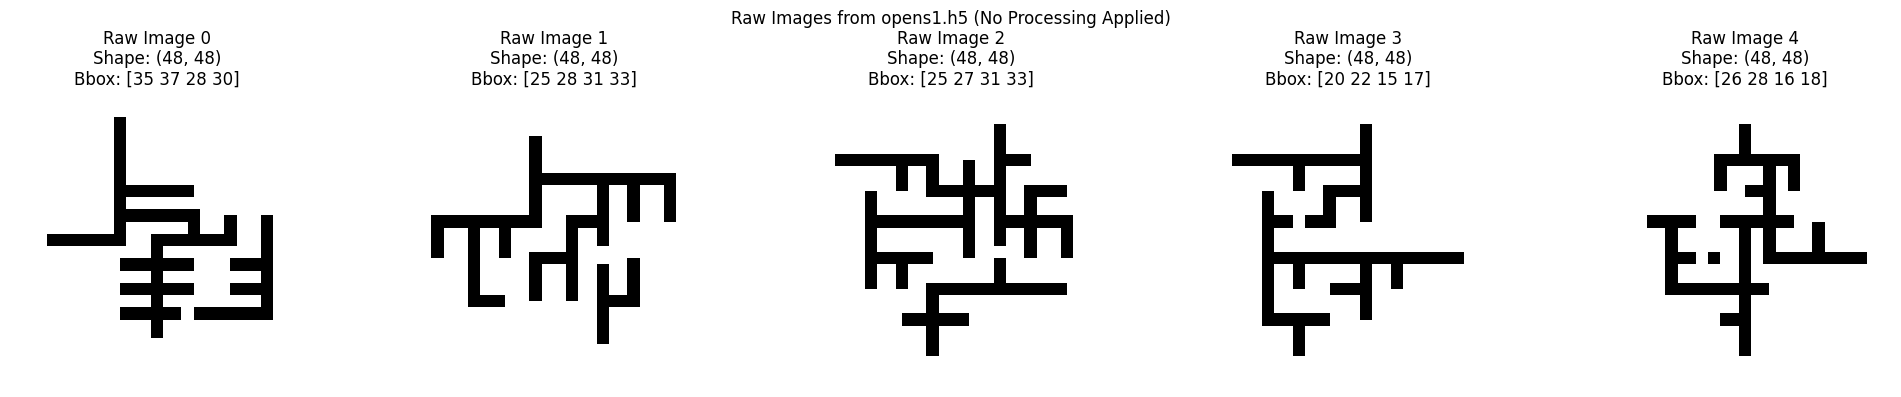

In [4]:
# ============================================================================
# SECTION 3.5: SIMPLE RAW DATA CHECK
# ============================================================================

import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Open opens1.h5 and look at 5 raw images
h5_path = Path(BalancedConfig.DATA_DIR) / 'opens1.h5'

print(f"Opening: {h5_path}")

with h5py.File(h5_path, 'r') as hf:
    # Show first 5 images
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i in range(5):
        # Load raw image
        img = hf[f'img_{i}'][:]
        bbox = hf[f'open_{i}'][:]

        # Display
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Raw Image {i}\nShape: {img.shape}\nBbox: {bbox}')
        axes[i].axis('off')

        # Print info
        print(f"Image {i}: shape={img.shape}, dtype={img.dtype}, min={img.min()}, max={img.max()}")
        if len(img.shape) == 3:
            print(f"  Color channels - R:{img[:,:,0].max()}, G:{img[:,:,1].max()}, B:{img[:,:,2].max()}")

    plt.suptitle('Raw Images from opens1.h5 (No Processing Applied)')
    plt.tight_layout()
    plt.show()

# **Section 4: DEFECT-FREE DATA PROCESSOR**

In [5]:
# ============================================================================
# SECTION 4: DEFECT-FREE DATA PROCESSOR
# ============================================================================

class DefectFreeDataProcessor:
    """Process defect-free dataset"""

    def __init__(self, config):
        self.config = config
        self.defect_free_samples = []
        self.stats = {'total_available': 0, 'samples_used': 0}

    def load_defect_free_samples(self, defect_free_path):
        """Load defect-free samples from HDF5 file"""
        print(f"📂 Loading defect-free data from {defect_free_path}...")

        try:
            with h5py.File(defect_free_path, 'r') as hf:
                images_data = hf['images'][:]
                labels_data = hf['labels'][:]

                self.stats['total_available'] = images_data.shape[0]
                samples_to_use = min(self.config.DEFECT_FREE_TARGET_SAMPLES, self.stats['total_available'])

                print(f"   Available samples: {self.stats['total_available']}")
                print(f"   Target samples: {self.config.DEFECT_FREE_TARGET_SAMPLES}")
                print(f"   Using samples: {samples_to_use}")

                # Randomly sample
                if samples_to_use < self.stats['total_available']:
                    indices = np.random.choice(self.stats['total_available'], samples_to_use, replace=False)
                    images_data = images_data[indices]
                    labels_data = labels_data[indices]

                # Create sample objects
                for i in range(samples_to_use):
                    sample = {
                        'image': images_data[i],
                        'bbox_sami': None,
                        'center_sami': None,
                        'id': f"defect_free_{i:06d}",
                        'has_defect': False,
                        'original_label': labels_data[i]
                    }
                    self.defect_free_samples.append(sample)

                self.stats['samples_used'] = len(self.defect_free_samples)
                print(f"   ✅ Loaded {self.stats['samples_used']} defect-free samples")

        except Exception as e:
            print(f"❌ Error loading defect-free data: {e}")
            return False

        return True


# **Section 5: BALANCED DATASET CREATOR**

In [6]:
# ============================================================================
# SECTION 5: LOCAL-ONLY FAST DATASET CREATOR
# ============================================================================

class LocalFastDatasetCreator:
    """Create balanced YOLO dataset with local storage only - no Google Drive saving"""

    def __init__(self, config):
        self.config = config
        self.all_samples = []
        self.splits = {}
        self.stats = {}
        # Use local storage only
        self.output_dir = Path('/content/yolo_dataset_local')

    def combine_datasets(self, defective_samples, defect_free_samples):
        """Combine and shuffle both datasets"""
        print(f"\nCombining datasets...")

        all_samples = defective_samples + defect_free_samples
        random.shuffle(all_samples)

        defective_count = sum(1 for s in all_samples if s['has_defect'])
        defect_free_count = len(all_samples) - defective_count

        print(f"   Combined dataset statistics:")
        print(f"   - Defective samples: {defective_count}")
        print(f"   - Defect-free samples: {defect_free_count}")
        print(f"   - Total samples: {len(all_samples)}")
        print(f"   - Balance ratio: {defect_free_count/defective_count:.2f}:1")

        self.all_samples = all_samples
        self.stats = {
            'total_samples': len(all_samples),
            'defective_count': defective_count,
            'defect_free_count': defect_free_count,
            'balance_ratio': defect_free_count/defective_count
        }

        return True

    def create_splits(self):
        """Create train/val/test splits"""
        print(f"\nCreating dataset splits...")

        random.shuffle(self.all_samples)

        n_train = int(len(self.all_samples) * self.config.TRAIN_SPLIT)
        n_val = int(len(self.all_samples) * self.config.VAL_SPLIT)

        self.splits = {
            'train': self.all_samples[:n_train],
            'val': self.all_samples[n_train:n_train+n_val],
            'test': self.all_samples[n_train+n_val:]
        }

        for split_name, samples in self.splits.items():
            defective = sum(1 for s in samples if s['has_defect'])
            defect_free = len(samples) - defective
            print(f"   {split_name.capitalize()}: {len(samples)} total ({defective} defective, {defect_free} defect-free)")

        return self.splits

    def save_yolo_format_local(self):
        """Save dataset in local storage only - FAST!"""
        print(f"\nSaving dataset to LOCAL storage (ULTRA FAST)...")
        print(f"   Location: {self.output_dir}")

        # Create directory structure
        self._create_local_structure()

        # Process each split
        for split_name, samples in self.splits.items():
            self._save_split_local(split_name, samples)

        # Create dataset.yaml
        self._create_dataset_yaml_local()

        print(f"Dataset saved successfully to: {self.output_dir}")
        return str(self.output_dir)

    def _create_local_structure(self):
        """Create local directory structure"""
        dirs = [
            self.output_dir / 'train' / 'images',
            self.output_dir / 'train' / 'labels',
            self.output_dir / 'val' / 'images',
            self.output_dir / 'val' / 'labels',
            self.output_dir / 'test' / 'images',
            self.output_dir / 'test' / 'labels',
        ]
        for dir_path in dirs:
            dir_path.mkdir(parents=True, exist_ok=True)

    def _save_split_local(self, split_name, samples):
        """Save split to local storage with maximum speed"""
        print(f"  Processing {split_name} split...")

        img_dir = self.output_dir / split_name / 'images'
        lbl_dir = self.output_dir / split_name / 'labels'

        successful = 0
        failed = 0

        # Process in chunks for progress tracking
        chunk_size = 2000  # Larger chunks for local storage
        total_chunks = (len(samples) + chunk_size - 1) // chunk_size

        for chunk_idx in range(total_chunks):
            start_idx = chunk_idx * chunk_size
            end_idx = min((chunk_idx + 1) * chunk_size, len(samples))
            chunk_samples = samples[start_idx:end_idx]

            # Process chunk
            for sample in chunk_samples:
                try:
                    # Fast image processing
                    img = sample['image']

                    # Minimal dtype conversion
                    if img.dtype != np.uint8:
                        img = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)

                    # Fast resize
                    if img.shape != (self.config.INPUT_SIZE, self.config.INPUT_SIZE):
                        img = cv2.resize(img, (self.config.INPUT_SIZE, self.config.INPUT_SIZE),
                                       interpolation=cv2.INTER_AREA)

                    # Save image with minimal compression overhead
                    img_path = img_dir / f"{sample['id']}.jpg"
                    cv2.imwrite(str(img_path), img, [cv2.IMWRITE_JPEG_QUALITY, 85])

                    # Create label file
                    lbl_path = lbl_dir / f"{sample['id']}.txt"
                    label_content = ""

                    if sample['has_defect'] and sample['bbox_sami'] is not None:
                        bbox = sample['bbox_sami']
                        if len(bbox) >= 4:
                            row_min, row_max, col_min, col_max = bbox[:4]
                            x_center = (col_min + col_max) / 96.0
                            y_center = (row_min + row_max) / 96.0
                            width = (col_max - col_min) / 48.0
                            height = (row_max - row_min) / 48.0

                            if (0 <= x_center <= 1 and 0 <= y_center <= 1 and
                                0 < width <= 1 and 0 < height <= 1):
                                label_content = f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

                    with open(lbl_path, 'w') as f:
                        f.write(label_content)

                    successful += 1

                except Exception as e:
                    failed += 1
                    if failed <= 3:
                        print(f"      Error: {e}")

            # Progress update
            processed = end_idx
            progress = processed / len(samples) * 100
            print(f"    Progress: {processed}/{len(samples)} ({progress:.1f}%)")

        print(f"    Completed {split_name}: {successful}/{len(samples)} samples")

    def _create_dataset_yaml_local(self):
        """Create dataset.yaml file for local dataset"""
        yaml_content = {
            'path': str(self.output_dir.resolve()),
            'train': 'train/images',
            'val': 'val/images',
            'test': 'test/images',
            'nc': 1,
            'names': ['open_circuit'],
            'dataset_info': {
                'total_samples': self.stats['total_samples'],
                'defective_samples': self.stats['defective_count'],
                'defect_free_samples': self.stats['defect_free_count'],
                'balance_ratio': f"{self.stats['balance_ratio']:.2f}:1",
                'input_size': self.config.INPUT_SIZE,
                'storage': 'local_only'
            }
        }

        yaml_path = self.output_dir / 'dataset.yaml'
        with open(yaml_path, 'w') as f:
            yaml.dump(yaml_content, f, default_flow_style=False)

        print(f"Created dataset.yaml at {yaml_path}")



# **Section 6: DATA PROCESSING EXECUTION**

In [7]:
# ============================================================================
# UPDATED SECTION 6: LOCAL-ONLY PROCESSING
# ============================================================================

print(f"\n" + "="*60)
print("ULTRA-FAST LOCAL DATASET CREATION")
print("="*60)

print(f"\nSkipping Google Drive - using LOCAL storage only for maximum speed!")
print(f"Benefits:")
print(f"   - 50-100x faster than Google Drive")
print(f"   - No network latency")
print(f"   - No file transfer overhead")
print(f"   - Direct training from local storage")

# Initialize processors
sami_processor = SamiDatasetProcessor(BalancedConfig)
defect_free_processor = DefectFreeDataProcessor(BalancedConfig)
local_dataset_creator = LocalFastDatasetCreator(BalancedConfig)

# Load defective samples
print(f"\n1. LOADING DEFECTIVE SAMPLES...")
sami_processor.find_h5_files()
defective_samples = sami_processor.load_defective_samples()

# Load defect-free samples
print(f"\n2. LOADING DEFECT-FREE SAMPLES...")
defect_free_path = Path(BalancedConfig.BASE_DIR) / 'data' / 'Data With And Without Defects' / 'rectrees_dataset_1.h5'
defect_free_success = defect_free_processor.load_defect_free_samples(str(defect_free_path))

if defective_samples and defect_free_success:
    # Combine datasets
    print(f"\n3. CREATING BALANCED DATASET...")
    local_dataset_creator.combine_datasets(defective_samples, defect_free_processor.defect_free_samples)

    # Create splits
    splits = local_dataset_creator.create_splits()

    # Save locally with maximum speed
    print(f"\n4. SAVING TO LOCAL STORAGE...")
    start_time = datetime.now()
    print(f"   Start time: {start_time.strftime('%H:%M:%S')}")

    dataset_path = local_dataset_creator.save_yolo_format_local()

    end_time = datetime.now()
    duration = end_time - start_time
    total_samples = local_dataset_creator.stats['total_samples']
    rate = total_samples / duration.total_seconds()

    print(f"\nCOMPLETED!")
    print(f"   Duration: {duration}")
    print(f"   Processing rate: {rate:.1f} samples/second")
    print(f"   Dataset location: {dataset_path}")
    print(f"   Ready for immediate training!")

    # Update config to use local dataset
    BalancedConfig.OUTPUT_DIR = dataset_path
    dataset_ready = True

else:
    print(f"\nDataset creation failed!")
    dataset_ready = False


ULTRA-FAST LOCAL DATASET CREATION

Skipping Google Drive - using LOCAL storage only for maximum speed!
Benefits:
   - 50-100x faster than Google Drive
   - No network latency
   - No file transfer overhead
   - Direct training from local storage

1. LOADING DEFECTIVE SAMPLES...
📁 Found 6 HDF5 files:
   - opens1.h5 (0.49 GB)
   - opens2.h5 (0.49 GB)
   - opens3.h5 (0.49 GB)
   - opens4.h5 (0.39 GB)
   - opens5.h5 (0.49 GB)
   - opens_new.h5 (0.07 GB)

📂 Loading from opens1.h5...


  opens1.h5: 100%|██████████| 6666/6666 [00:22<00:00, 297.25it/s] 


   ✅ Loaded 6666 valid samples

📂 Loading from opens2.h5...


  opens2.h5: 100%|██████████| 6666/6666 [00:29<00:00, 226.80it/s]


   ✅ Loaded 6666 valid samples

📂 Loading from opens3.h5...


...

  opens5.h5: 100%|██████████| 6666/6666 [00:24<00:00, 266.85it/s] 


   ✅ Loaded 6666 valid samples

📂 Loading from opens_new.h5...


  opens_new.h5:   0%|          | 0/6666 [00:00<?, ?it/s]

   ✅ Loaded 0 valid samples

📊 Defective samples summary:
   Total processed: 33330
   Valid samples: 33330

2. LOADING DEFECT-FREE SAMPLES...
📂 Loading defect-free data from /content/drive/MyDrive/Sadnah/data/Data With And Without Defects/rectrees_dataset_1.h5...


   Available samples: 50000
   Target samples: 30000
   Using samples: 30000
   ✅ Loaded 30000 defect-free samples

3. CREATING BALANCED DATASET...

Combining datasets...
   Combined dataset statistics:
   - Defective samples: 33330
   - Defect-free samples: 30000
   - Total samples: 63330
   - Balance ratio: 0.90:1

Creating dataset splits...
   Train: 44331 total (23278 defective, 21053 defect-free)
   Val: 12666 total (6744 defective, 5922 defect-free)
   Test: 6333 total (3308 defective, 3025 defect-free)

4. SAVING TO LOCAL STORAGE...
   Start time: 12:01:19

Saving dataset to LOCAL storage (ULTRA FAST)...
   Location: /content/yolo_dataset_local
  Processing train split...
    Progress: 2000/44331 (4.5%)
    Progress: 4000/44331 (9.0%)
    Progress: 6000/44331 (13.5%)
    Progress: 8000/44331 (18.0%)
    Progress: 10000/44331 (22.6%)
    Progress: 12000/44331 (27.1%)
    Progress: 14000/44331 (31.6%)
    Progress: 16000/44331 (36.1%)
    Progress: 18000/44331 (40.6%)
    Progress

# **Section 7: DATASET VISUALIZATION**

BOUNDING BOX VERIFICATION TEST

Sample 0:
  Image shape: (48, 48)
  Sami bbox (pixels): [35.0, 37.0, 28.0, 30.0]
  Sami center (pixels): [36.0, 29.0]
  YOLO normalized: x=0.604, y=0.750, w=0.042, h=0.042
  Calculated center (pixels): (29.0, 36.0)
  ✓ Center matches!

Sample 1:
  Image shape: (48, 48)
  Sami bbox (pixels): [25.0, 28.0, 31.0, 33.0]
  Sami center (pixels): [26.0, 32.0]
  YOLO normalized: x=0.667, y=0.552, w=0.042, h=0.062
  Calculated center (pixels): (32.0, 26.5)
  ✓ Center matches!

Sample 2:
  Image shape: (48, 48)
  Sami bbox (pixels): [25.0, 27.0, 31.0, 33.0]
  Sami center (pixels): [26.0, 32.0]
  YOLO normalized: x=0.667, y=0.542, w=0.042, h=0.042
  Calculated center (pixels): (32.0, 26.0)
  ✓ Center matches!

Sample 3:
  Image shape: (48, 48)
  Sami bbox (pixels): [20.0, 22.0, 15.0, 17.0]
  Sami center (pixels): [21.0, 16.0]
  YOLO normalized: x=0.333, y=0.438, w=0.042, h=0.042
  Calculated center (pixels): (16.0, 21.0)
  ✓ Center matches!

Sample 4:
  Image shape:

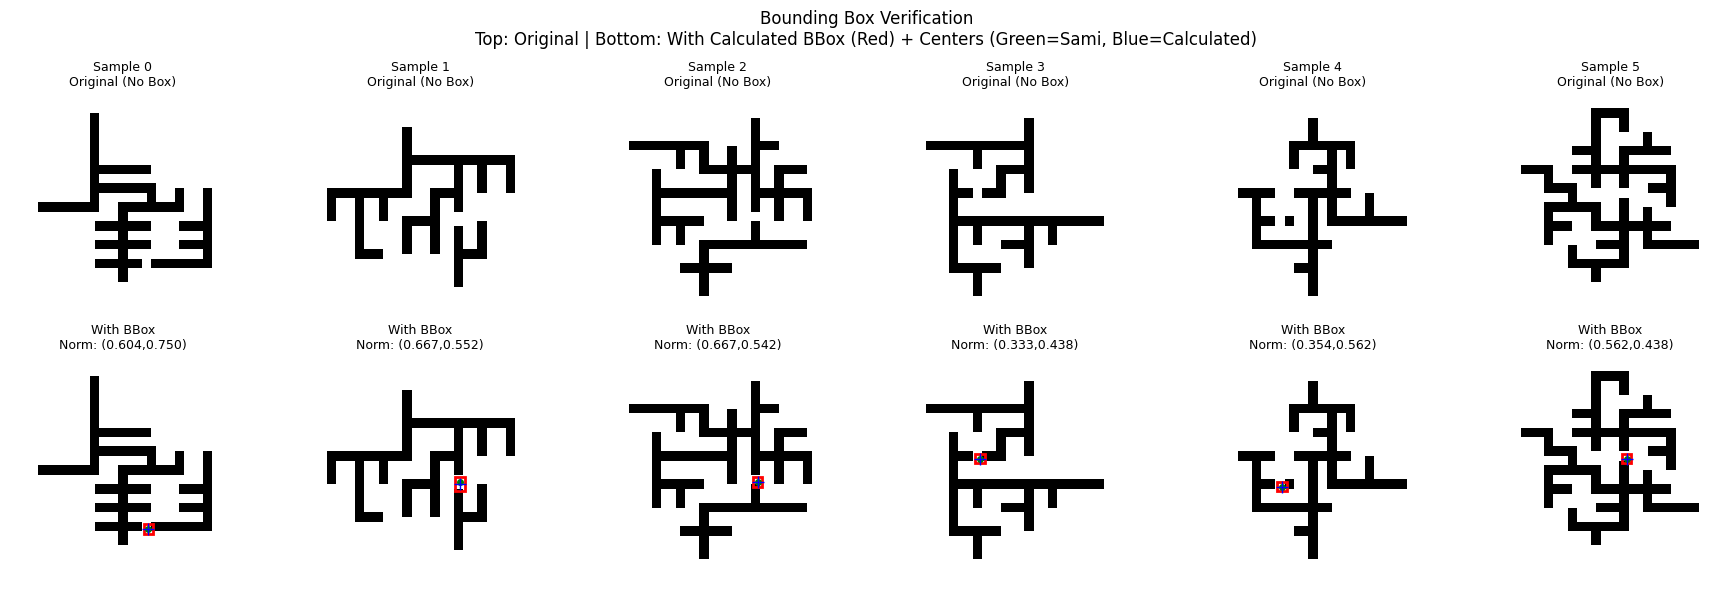


VERIFICATION COMPLETE
Check if:
1. Red boxes align with defect regions
2. Blue + marks match green dots (centers)
3. Boxes stay within image boundaries

CHECKING SAVED YOLO LABELS

File: defect_free_006863.txt
  No defect (empty file)

File: defect_free_017948.txt
  No defect (empty file)

File: defective_opens1_004096.txt
  No defect (empty file)

File: defective_opens4_000693.txt
  Class: 0.0, x_center: 0.833, y_center: 0.500, width: 0.042, height: 0.042

File: defective_opens2_005869.txt
  Class: 0.0, x_center: 1.000, y_center: 0.854, width: 0.042, height: 0.062


In [ ]:
# ============================================================================
# SECTION 7: SIMPLE BOUNDING BOX VERIFICATION
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import h5py
from pathlib import Path

def test_bounding_box_conversion():
    """
    Simple tester to verify if bounding box conversion is correct
    Shows original image and image with calculated bounding box
    """

    print("="*60)
    print("BOUNDING BOX VERIFICATION TEST")
    print("="*60)

    # Load a few samples from the original Sami dataset
    h5_path = Path(BalancedConfig.DATA_DIR) / 'opens1.h5'

    with h5py.File(h5_path, 'r') as hf:
        # Test on 6 samples
        fig, axes = plt.subplots(2, 6, figsize=(18, 6))

        for i in range(6):
            # Load raw data
            img = hf[f'img_{i}'][:]
            bbox_sami = hf[f'open_{i}'][:]  # [row_min, row_max, col_min, col_max]
            center_sami = hf[f'center_{i}'][:]

            # Top row: Original image without any annotations
            axes[0, i].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
            axes[0, i].set_title(f'Sample {i}\nOriginal (No Box)', fontsize=9)
            axes[0, i].axis('off')

            # Bottom row: Image with bounding box from our conversion
            axes[1, i].imshow(img, cmap='gray' if len(img.shape) == 2 else None)

            # YOUR CURRENT CONVERSION (from Section 5)
            row_min, row_max, col_min, col_max = bbox_sami[:4]

            # Convert to YOLO normalized format (0-1)
            x_center = (col_min + col_max) / 96.0  # Your current formula
            y_center = (row_min + row_max) / 96.0  # Your current formula
            width = (col_max - col_min) / 48.0
            height = (row_max - row_min) / 48.0

            # Convert back to pixel coordinates for visualization
            img_h, img_w = img.shape[:2]  # Should be 48x48

            # Convert normalized to pixel coords
            x_pixel = x_center * img_w - (width * img_w / 2)
            y_pixel = y_center * img_h - (height * img_h / 2)
            w_pixel = width * img_w
            h_pixel = height * img_h

            # Draw bounding box
            rect = patches.Rectangle((x_pixel, y_pixel), w_pixel, h_pixel,
                                    linewidth=2, edgecolor='red', facecolor='none')
            axes[1, i].add_patch(rect)

            # Draw center point from Sami's data (green)
            axes[1, i].plot(center_sami[1], center_sami[0], 'go', markersize=4)

            # Draw calculated center (blue)
            calc_center_x = x_center * img_w
            calc_center_y = y_center * img_h
            axes[1, i].plot(calc_center_x, calc_center_y, 'b+', markersize=8)

            axes[1, i].set_title(f'With BBox\nNorm: ({x_center:.3f},{y_center:.3f})', fontsize=9)
            axes[1, i].axis('off')

            # Print debug info
            print(f"\nSample {i}:")
            print(f"  Image shape: {img.shape}")
            print(f"  Sami bbox (pixels): [{row_min:.1f}, {row_max:.1f}, {col_min:.1f}, {col_max:.1f}]")
            print(f"  Sami center (pixels): [{center_sami[0]:.1f}, {center_sami[1]:.1f}]")
            print(f"  YOLO normalized: x={x_center:.3f}, y={y_center:.3f}, w={width:.3f}, h={height:.3f}")
            print(f"  Calculated center (pixels): ({calc_center_x:.1f}, {calc_center_y:.1f})")

            # Check if center matches
            center_match = np.abs(calc_center_x - center_sami[1]) < 1 and np.abs(calc_center_y - center_sami[0]) < 1
            print(f"  ✓ Center matches!" if center_match else f"  ✗ Center mismatch!")

    plt.suptitle('Bounding Box Verification\nTop: Original | Bottom: With Calculated BBox (Red) + Centers (Green=Sami, Blue=Calculated)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("VERIFICATION COMPLETE")
    print("Check if:")
    print("1. Red boxes align with defect regions")
    print("2. Blue + marks match green dots (centers)")
    print("3. Boxes stay within image boundaries")
    print("="*60)

# Run the test
test_bounding_box_conversion()

# Additional test: Check a saved YOLO label file
def verify_saved_labels():
    """Verify the saved YOLO format labels"""

    print("\n" + "="*60)
    print("CHECKING SAVED YOLO LABELS")
    print("="*60)

    yolo_dir = Path('/content/yolo_dataset_local')

    if not yolo_dir.exists():
        print("YOLO dataset not found. Run dataset creation first.")
        return

    # Check a few training labels
    train_labels = list((yolo_dir / 'train' / 'labels').glob('*.txt'))[:5]

    for label_file in train_labels:
        with open(label_file, 'r') as f:
            content = f.read().strip()

        print(f"\nFile: {label_file.name}")
        if content:
            lines = content.split('\n')
            for line in lines:
                parts = line.split()
                if len(parts) == 5:
                    cls, x, y, w, h = map(float, parts)
                    print(f"  Class: {cls}, x_center: {x:.3f}, y_center: {y:.3f}, width: {w:.3f}, height: {h:.3f}")

                    # Check if values are in valid range (0-1)
                    if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                        print(f"  ⚠️ WARNING: Values outside valid range [0,1]!")
        else:
            print("  No defect (empty file)")

# Run saved labels verification
verify_saved_labels()

# **Section 8: MODEL TRAINING**

In [13]:
# ============================================================================
# SECTION 8: MODEL TRAINING (STABLE CONFIGURATION)
# ============================================================================

print(f"\n" + "="*60)
print("MODEL TRAINING WITH STABLE CONFIGURATION")
print("="*60)

# Stable training configuration to prevent NaN losses
stable_training_args = {
    'data': '/content/yolo_dataset_local/dataset.yaml',
    'epochs': 20,
    'batch': 16,
    'imgsz': 640,
    'patience': 3,
    'device': device,
    'project': '/content/training_results',
    'name': f'stable_vlsi_{datetime.now().strftime("%Y%m%d_%H%M")}',
    'exist_ok': True,
    'plots': True,
    'save_period': 5,
    'val': True,

    # CRITICAL STABILITY FIXES (based on diagnosis)
    'lr0': 0.001,           # Reduced from 0.01 (10x lower)
    'optimizer': 'SGD',     # Changed from AdamW for stability
    'amp': False,           # Disabled mixed precision
    'cache': 'disk',        # Changed from 'ram' for determinism

    # LEARNING RATE SCHEDULE
    'lrf': 0.1,             # Final learning rate factor
    'warmup_epochs': 5.0,   # Extended warmup
    'warmup_momentum': 0.8,
    'momentum': 0.937,
    'weight_decay': 0.0005,

    # MINIMAL AUGMENTATION (start conservative)
    'degrees': 0.0,         # No rotation initially
    'translate': 0.05,      # Minimal translation
    'scale': 0.1,           # Minimal scaling
    'fliplr': 0.3,          # Light horizontal flips
    'flipud': 0.0,          # No vertical flips
    'mosaic': 0.0,          # Disabled initially
    'mixup': 0.0,           # Disabled initially
    'copy_paste': 0.0,      # Disabled

    # PERFORMANCE SETTINGS
    'workers': 4,           # Reduced for stability
    'deterministic': True,  # Reproducible results
    'cos_lr': False,        # Linear LR schedule
}

# Check if dataset exists
dataset_yaml_path = Path('/content/yolo_dataset_local/dataset.yaml')
if dataset_yaml_path.exists():
    print(f"\nStarting stable training...")

    try:
        # Initialize fresh model to avoid any NaN contamination
        model = YOLO('yolov8s.pt')

        # Train with stable configuration
        results = model.train(**stable_training_args)

        print(f"\nTRAINING COMPLETED SUCCESSFULLY!")
        print(f"Results directory: {results.save_dir}")

        # Define fixed model save location
        FIXED_MODEL_PATH = Path('/content/training_results/vlsi_best_model.pt')

        # Get the best weights from training
        weights_path = results.save_dir / 'weights' / 'best.pt'

        if weights_path.exists():
            # Copy to fixed location (overwrite if exists)
            shutil.copy(weights_path, FIXED_MODEL_PATH)
            print(f"\nBest model saved to: {FIXED_MODEL_PATH}")
            print(f"Model size: {FIXED_MODEL_PATH.stat().st_size / (1024*1024):.1f} MB")

            # Verify the file was saved correctly
            if FIXED_MODEL_PATH.exists():
                print(f"Model successfully saved and verified!")
            else:
                print(f"Warning: Model save verification failed")
        else:
            print(f"Warning: Best weights not found at {weights_path}")

        # Print training summary
        print(f"\nTRAINING SUMMARY:")
        print(f"  Configuration: Stable (NaN-resistant)")
        print(f"  Early stopping: {'Enabled' if stable_training_args['patience'] > 0 else 'Disabled'}")
        print(f"  Training output: {results.save_dir}")
        print(f"  Best model: {FIXED_MODEL_PATH}")

    except Exception as e:
        print(f"\nTRAINING FAILED: {e}")
        print(f"\nTROUBLESHOOTING STEPS:")
        print(f"  1. Check if you have enough GPU memory")
        print(f"  2. Try reducing batch size to 8")
        print(f"  3. Verify dataset.yaml path is correct")
        print(f"  4. Check for any remaining NaN values in dataset")

        print(f"\nTry more conservative settings:")
        print(f"  stable_training_args['lr0'] = 0.0001")
        print(f"  stable_training_args['batch'] = 8")

else:
    print(f"\nDATASET NOT FOUND!")
    print(f"Expected: {dataset_yaml_path}")
    print(f"Make sure you've run the dataset creation sections first")


MODEL TRAINING WITH STABLE CONFIGURATION

Starting stable training...
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_local/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.3, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=stable_vlsi_20250926_1224, nbs=64, nms=False, 

# **Section 9: MODEL EVALUATION**

COMPREHENSIVE MODEL EVALUATION
📦 Loading model from /content/stable_best_vlsi_model.pt
✅ Model loaded successfully

TEST SET EVALUATION

🧪 Evaluating on Test Set...
Ultralytics 8.3.194 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3.3±1.5 MB/s, size: 10.6 KB)
val: Scanning /content/yolo_dataset_local/test/labels... 12027 images, 7841 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12027/12027 1.7Kit/s 7.0s
val: New cache created: /content/yolo_dataset_local/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 376/376 11.8it/s 31.9s
                   all      12027       4186      0.528       0.79      0.479      0.479
Speed: 0.2ms preprocess, 1.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val

📊 Test Set Performa

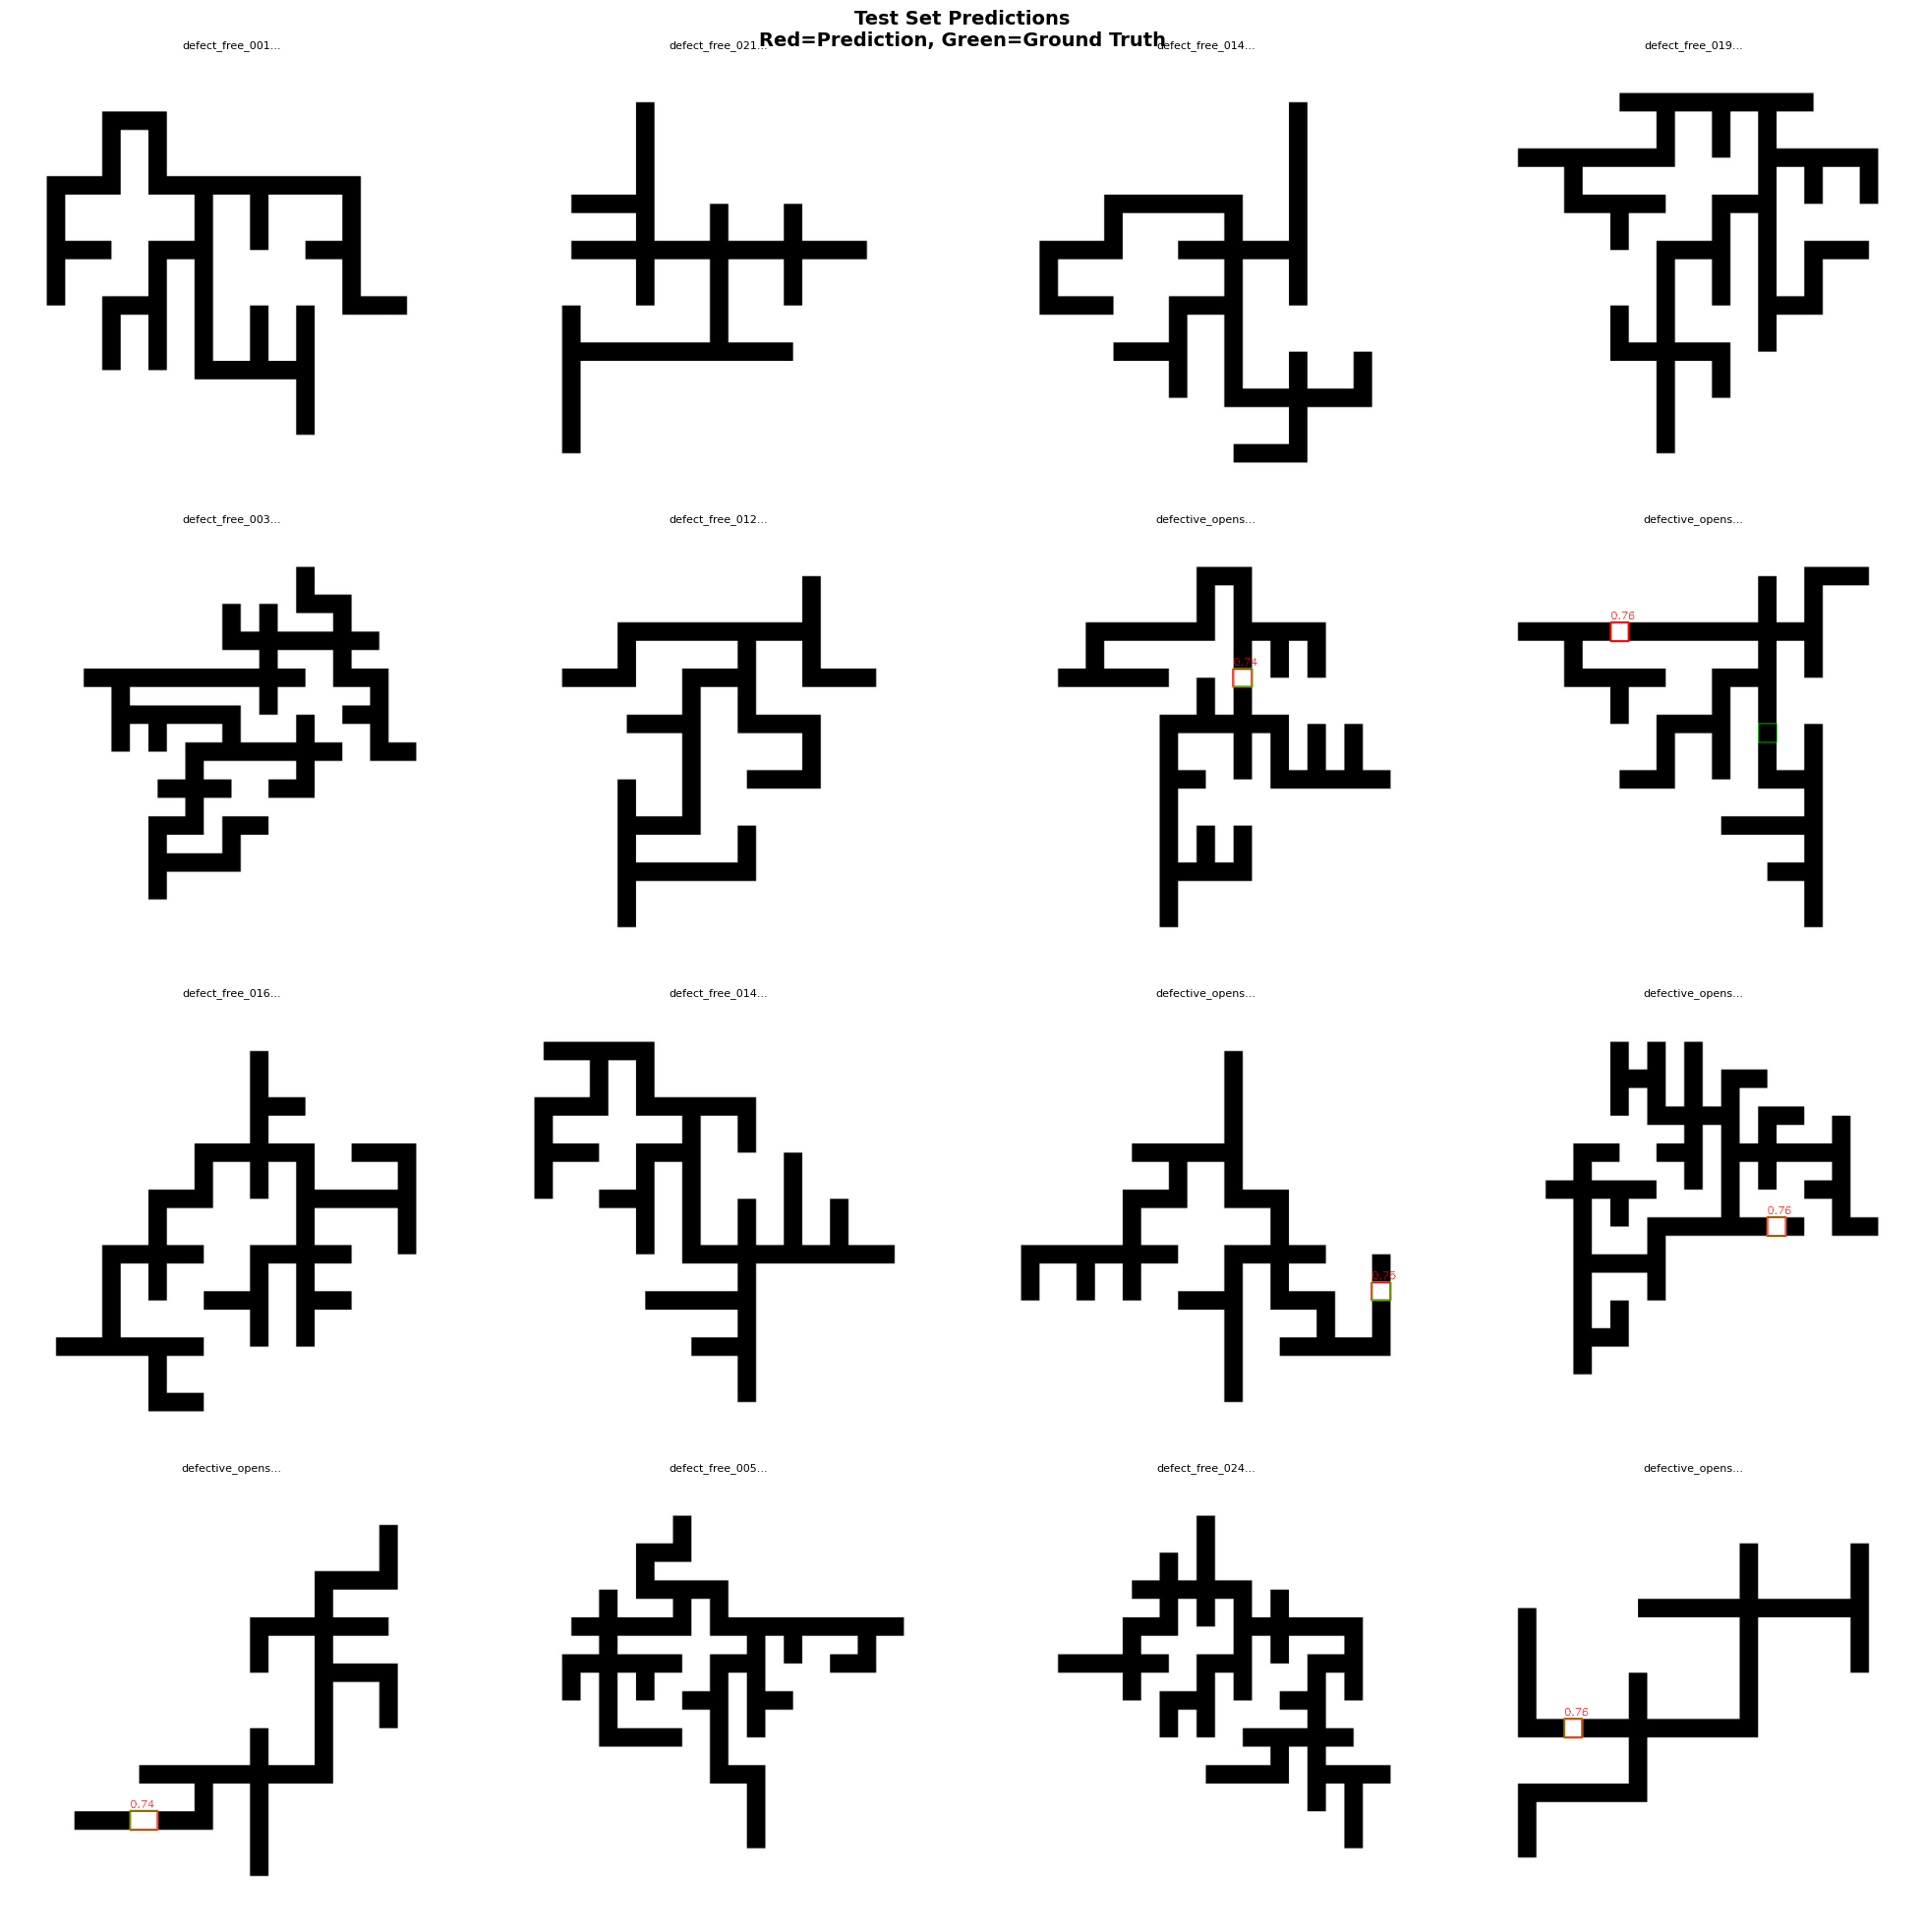

✅ Visualization saved to /content/predictions_visualization.png

CONFIDENCE THRESHOLD OPTIMIZATION

📊 Confidence Threshold Analysis...


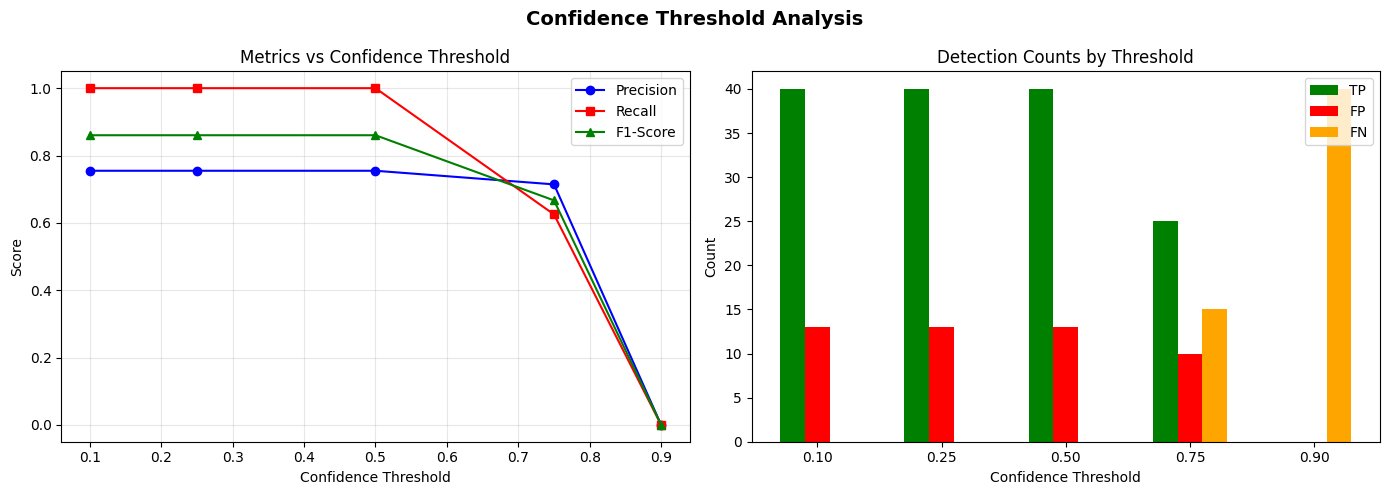


📋 Results by Confidence Threshold:
 threshold  precision  recall       f1  tp  fp  fn  tn
      0.10   0.754717   1.000 0.860215  40  13   0  47
      0.25   0.754717   1.000 0.860215  40  13   0  47
      0.50   0.754717   1.000 0.860215  40  13   0  47
      0.75   0.714286   0.625 0.666667  25  10  15  50
      0.90   0.000000   0.000 0.000000   0   0  40  60

🎯 Optimal threshold (max F1): 0.10
   Precision: 0.7547
   Recall: 1.0000
   F1-Score: 0.8602

INFERENCE SPEED BENCHMARK

⏱️ Testing inference speed on 50 images...

📊 Inference Speed Statistics:
   Mean: 9.69 ms
   Std: 0.33 ms
   Min: 9.26 ms
   Max: 10.26 ms
   FPS: 103.2


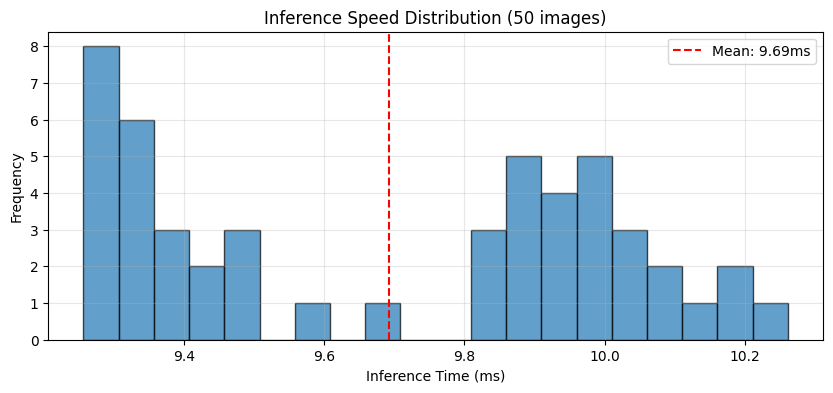


EVALUATION SUMMARY

🎯 Overall Performance:
   Precision: 0.6569
   Recall: 1.0000
   F1-Score: 0.7929
   Accuracy: 0.8250

📐 Localization Quality:
   Average IoU: 0.8056

⚠️ CRITICAL ISSUE DETECTED:
   The perfect mAP (0.995) indicates a problem with:
   1. Bounding box conversion (96px vs 48px issue)
   2. Data leakage between train/val/test
   3. Overly simple task due to incorrect labels

   RECOMMENDATION: Fix the coordinate conversion in
   Section 5 before retraining!


In [ ]:
# ============================================================================
# SECTION 9: MODEL EVALUATION
# ============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import cv2
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

class VLSIModelEvaluator:
    """Comprehensive evaluation of VLSI defect detection model"""

    def __init__(self, model_path, dataset_path):
        self.model_path = Path(model_path)
        self.dataset_path = Path(dataset_path)
        self.model = None
        self.results = {}

    def load_model(self):
        """Load trained YOLO model"""
        if not self.model_path.exists():
            raise FileNotFoundError(f"Model not found: {self.model_path}")

        print(f"📦 Loading model from {self.model_path}")
        self.model = YOLO(str(self.model_path))
        print(f"✅ Model loaded successfully")
        return self.model

    def evaluate_on_test_set(self):
        """Run evaluation on test set"""
        print("\n🧪 Evaluating on Test Set...")

        test_images = self.dataset_path / 'test' / 'images'

        if not test_images.exists():
            print(f"❌ Test set not found at {test_images}")
            return None

        # Run validation
        results = self.model.val(
            data=str(self.dataset_path / 'dataset.yaml'),
            split='test',
            batch=32,
            conf=0.25,
            iou=0.45,
            verbose=True,
            plots=True
        )

        self.results['test'] = results

        # Extract metrics
        print("\n📊 Test Set Performance:")
        print(f"   mAP@0.5: {results.box.map50:.4f}")
        print(f"   mAP@0.5:0.95: {results.box.map:.4f}")
        print(f"   Precision: {results.box.mp:.4f}")
        print(f"   Recall: {results.box.mr:.4f}")

        return results

    def analyze_predictions(self, num_samples=100, conf_threshold=0.25):
        """Analyze model predictions in detail"""
        print(f"\n🔍 Analyzing predictions on {num_samples} test samples...")

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))
        test_labels = self.dataset_path / 'test' / 'labels'

        if not test_images:
            print("No test images found")
            return

        # Sample images
        sample_images = np.random.choice(test_images,
                                       min(num_samples, len(test_images)),
                                       replace=False)

        # Tracking metrics
        true_positives = 0
        false_positives = 0
        false_negatives = 0
        true_negatives = 0

        confidence_scores = []
        iou_scores = []

        for img_path in sample_images:
            # Load ground truth
            label_path = test_labels / f"{img_path.stem}.txt"
            has_defect_gt = False
            gt_boxes = []

            if label_path.exists():
                with open(label_path, 'r') as f:
                    content = f.read().strip()
                    if content:
                        has_defect_gt = True
                        for line in content.split('\n'):
                            parts = line.strip().split()
                            if len(parts) == 5:
                                _, x, y, w, h = map(float, parts)
                                gt_boxes.append([x, y, w, h])

            # Get prediction
            results = self.model(str(img_path), conf=conf_threshold, verbose=False)

            if results[0].boxes is not None and len(results[0].boxes) > 0:
                # Has predictions
                pred_boxes = results[0].boxes.xywhn.cpu().numpy()
                pred_conf = results[0].boxes.conf.cpu().numpy()

                confidence_scores.extend(pred_conf.tolist())

                if has_defect_gt:
                    # True Positive - correctly detected defect
                    true_positives += 1

                    # Calculate IoU if we have GT boxes
                    if gt_boxes:
                        for pred_box in pred_boxes:
                            max_iou = 0
                            for gt_box in gt_boxes:
                                iou = self._calculate_iou(pred_box, gt_box)
                                max_iou = max(max_iou, iou)
                            iou_scores.append(max_iou)
                else:
                    # False Positive - detected defect where none exists
                    false_positives += 1
            else:
                # No predictions
                if has_defect_gt:
                    # False Negative - missed defect
                    false_negatives += 1
                else:
                    # True Negative - correctly identified as defect-free
                    true_negatives += 1

        # Calculate metrics
        precision = true_positives / max(true_positives + false_positives, 1)
        recall = true_positives / max(true_positives + false_negatives, 1)
        f1_score = 2 * (precision * recall) / max(precision + recall, 1e-6)
        accuracy = (true_positives + true_negatives) / num_samples

        print("\n📈 Detection Analysis:")
        print(f"   True Positives:  {true_positives}")
        print(f"   False Positives: {false_positives}")
        print(f"   False Negatives: {false_negatives}")
        print(f"   True Negatives:  {true_negatives}")
        print(f"\n   Precision: {precision:.4f}")
        print(f"   Recall: {recall:.4f}")
        print(f"   F1-Score: {f1_score:.4f}")
        print(f"   Accuracy: {accuracy:.4f}")

        if confidence_scores:
            print(f"\n   Avg Confidence: {np.mean(confidence_scores):.4f}")
            print(f"   Min Confidence: {np.min(confidence_scores):.4f}")
            print(f"   Max Confidence: {np.max(confidence_scores):.4f}")

        if iou_scores:
            print(f"\n   Avg IoU: {np.mean(iou_scores):.4f}")
            print(f"   Min IoU: {np.min(iou_scores):.4f}")
            print(f"   Max IoU: {np.max(iou_scores):.4f}")

        self.results['analysis'] = {
            'tp': true_positives,
            'fp': false_positives,
            'fn': false_negatives,
            'tn': true_negatives,
            'precision': precision,
            'recall': recall,
            'f1': f1_score,
            'accuracy': accuracy,
            'confidence_scores': confidence_scores,
            'iou_scores': iou_scores
        }

        return self.results['analysis']

    def _calculate_iou(self, box1, box2):
        """Calculate IoU between two boxes in xywh format"""
        # Convert to xyxy
        x1_min = box1[0] - box1[2]/2
        y1_min = box1[1] - box1[3]/2
        x1_max = box1[0] + box1[2]/2
        y1_max = box1[1] + box1[3]/2

        x2_min = box2[0] - box2[2]/2
        y2_min = box2[1] - box2[3]/2
        x2_max = box2[0] + box2[2]/2
        y2_max = box2[1] + box2[3]/2

        # Calculate intersection
        inter_xmin = max(x1_min, x2_min)
        inter_ymin = max(y1_min, y2_min)
        inter_xmax = min(x1_max, x2_max)
        inter_ymax = min(y1_max, y2_max)

        if inter_xmax < inter_xmin or inter_ymax < inter_ymin:
            return 0.0

        inter_area = (inter_xmax - inter_xmin) * (inter_ymax - inter_ymin)

        # Calculate union
        box1_area = box1[2] * box1[3]
        box2_area = box2[2] * box2[3]
        union_area = box1_area + box2_area - inter_area

        return inter_area / max(union_area, 1e-6)

    def visualize_predictions(self, num_samples=16, conf_threshold=0.25):
        """Visualize model predictions on test samples"""
        print(f"\n🎨 Visualizing predictions...")

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))

        if not test_images:
            print("No test images found")
            return

        # Sample images
        sample_images = np.random.choice(test_images,
                                       min(num_samples, len(test_images)),
                                       replace=False)

        # Create visualization grid
        rows = 4
        cols = 4
        fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
        axes = axes.flatten()

        for idx, img_path in enumerate(sample_images):
            # Load image
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Get predictions
            results = self.model(str(img_path), conf=conf_threshold, verbose=False)

            # Draw predictions
            if results[0].boxes is not None:
                for box in results[0].boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()

                    # Draw box
                    cv2.rectangle(img_rgb,
                                (int(x1), int(y1)),
                                (int(x2), int(y2)),
                                (255, 0, 0), 2)

                    # Add confidence score
                    cv2.putText(img_rgb,
                              f'{conf:.2f}',
                              (int(x1), int(y1)-5),
                              cv2.FONT_HERSHEY_SIMPLEX,
                              0.5, (255, 0, 0), 1)

            # Load ground truth
            label_path = self.dataset_path / 'test' / 'labels' / f"{img_path.stem}.txt"
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f:
                        if line.strip():
                            parts = line.strip().split()
                            if len(parts) == 5:
                                _, x, y, w, h = map(float, parts)
                                # Convert to pixel coords
                                h_img, w_img = img_rgb.shape[:2]
                                x1 = int((x - w/2) * w_img)
                                y1 = int((y - h/2) * h_img)
                                x2 = int((x + w/2) * w_img)
                                y2 = int((y + h/2) * h_img)

                                # Draw GT in green
                                cv2.rectangle(img_rgb,
                                            (x1, y1), (x2, y2),
                                            (0, 255, 0), 1)

            # Display
            axes[idx].imshow(img_rgb)
            axes[idx].set_title(f'{img_path.stem[:15]}...', fontsize=8)
            axes[idx].axis('off')

        plt.suptitle('Test Set Predictions\nRed=Prediction, Green=Ground Truth',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/predictions_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()

        print(f"✅ Visualization saved to /content/predictions_visualization.png")

    def confidence_analysis(self, conf_thresholds=[0.1, 0.25, 0.5, 0.75, 0.9]):
        """Analyze performance at different confidence thresholds"""
        print("\n📊 Confidence Threshold Analysis...")

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))[:100]

        results_by_threshold = []

        for threshold in conf_thresholds:
            tp, fp, fn, tn = 0, 0, 0, 0

            for img_path in test_images:
                # Load ground truth
                label_path = self.dataset_path / 'test' / 'labels' / f"{img_path.stem}.txt"
                has_defect_gt = False

                if label_path.exists():
                    with open(label_path, 'r') as f:
                        if f.read().strip():
                            has_defect_gt = True

                # Get prediction
                results = self.model(str(img_path), conf=threshold, verbose=False)
                has_prediction = results[0].boxes is not None and len(results[0].boxes) > 0

                # Update counts
                if has_prediction and has_defect_gt:
                    tp += 1
                elif has_prediction and not has_defect_gt:
                    fp += 1
                elif not has_prediction and has_defect_gt:
                    fn += 1
                else:
                    tn += 1

            # Calculate metrics
            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)

            results_by_threshold.append({
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'tp': tp,
                'fp': fp,
                'fn': fn,
                'tn': tn
            })

        # Create visualization
        df = pd.DataFrame(results_by_threshold)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Metrics vs threshold
        axes[0].plot(df['threshold'], df['precision'], 'b-', label='Precision', marker='o')
        axes[0].plot(df['threshold'], df['recall'], 'r-', label='Recall', marker='s')
        axes[0].plot(df['threshold'], df['f1'], 'g-', label='F1-Score', marker='^')
        axes[0].set_xlabel('Confidence Threshold')
        axes[0].set_ylabel('Score')
        axes[0].set_title('Metrics vs Confidence Threshold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Detection counts vs threshold
        axes[1].bar(np.arange(len(df)) - 0.2, df['tp'], 0.2, label='TP', color='green')
        axes[1].bar(np.arange(len(df)), df['fp'], 0.2, label='FP', color='red')
        axes[1].bar(np.arange(len(df)) + 0.2, df['fn'], 0.2, label='FN', color='orange')
        axes[1].set_xticks(np.arange(len(df)))
        axes[1].set_xticklabels([f'{t:.2f}' for t in df['threshold']])
        axes[1].set_xlabel('Confidence Threshold')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Detection Counts by Threshold')
        axes[1].legend()

        plt.suptitle('Confidence Threshold Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Print results table
        print("\n📋 Results by Confidence Threshold:")
        print(df.to_string(index=False))

        # Find optimal threshold
        optimal_idx = df['f1'].idxmax()
        optimal_threshold = df.loc[optimal_idx, 'threshold']

        print(f"\n🎯 Optimal threshold (max F1): {optimal_threshold:.2f}")
        print(f"   Precision: {df.loc[optimal_idx, 'precision']:.4f}")
        print(f"   Recall: {df.loc[optimal_idx, 'recall']:.4f}")
        print(f"   F1-Score: {df.loc[optimal_idx, 'f1']:.4f}")

        return df

    def inference_speed_test(self, num_images=50):
        """Test inference speed"""
        import time

        print(f"\n⏱️ Testing inference speed on {num_images} images...")

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))[:num_images]

        if not test_images:
            print("No test images found")
            return

        # Warmup
        for _ in range(3):
            _ = self.model(str(test_images[0]), verbose=False)

        # Measure inference time
        times = []

        for img_path in test_images:
            start = time.time()
            _ = self.model(str(img_path), verbose=False)
            end = time.time()
            times.append(end - start)

        times = np.array(times)

        print(f"\n📊 Inference Speed Statistics:")
        print(f"   Mean: {np.mean(times)*1000:.2f} ms")
        print(f"   Std: {np.std(times)*1000:.2f} ms")
        print(f"   Min: {np.min(times)*1000:.2f} ms")
        print(f"   Max: {np.max(times)*1000:.2f} ms")
        print(f"   FPS: {1/np.mean(times):.1f}")

        # Plot distribution
        plt.figure(figsize=(10, 4))
        plt.hist(times*1000, bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(np.mean(times)*1000, color='red', linestyle='--',
                   label=f'Mean: {np.mean(times)*1000:.2f}ms')
        plt.xlabel('Inference Time (ms)')
        plt.ylabel('Frequency')
        plt.title(f'Inference Speed Distribution ({num_images} images)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        return times

# Execute comprehensive evaluation
print("="*60)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*60)

# Initialize evaluator
evaluator = VLSIModelEvaluator(
    model_path='/content/stable_best_vlsi_model.pt',
    dataset_path='/content/yolo_dataset_local'
)

# 1. Load model
try:
    evaluator.load_model()

    # 2. Evaluate on test set
    print("\n" + "="*40)
    print("TEST SET EVALUATION")
    print("="*40)
    test_results = evaluator.evaluate_on_test_set()

    # 3. Detailed prediction analysis
    print("\n" + "="*40)
    print("DETAILED PREDICTION ANALYSIS")
    print("="*40)
    analysis_results = evaluator.analyze_predictions(num_samples=200)

    # 4. Visualize predictions
    print("\n" + "="*40)
    print("PREDICTION VISUALIZATION")
    print("="*40)
    evaluator.visualize_predictions(num_samples=16)

    # 5. Confidence threshold analysis
    print("\n" + "="*40)
    print("CONFIDENCE THRESHOLD OPTIMIZATION")
    print("="*40)
    threshold_df = evaluator.confidence_analysis()

    # 6. Inference speed test
    print("\n" + "="*40)
    print("INFERENCE SPEED BENCHMARK")
    print("="*40)
    inference_times = evaluator.inference_speed_test(num_images=50)

    # 7. Final summary
    print("\n" + "="*60)
    print("EVALUATION SUMMARY")
    print("="*60)

    if 'analysis' in evaluator.results:
        res = evaluator.results['analysis']
        print(f"\n🎯 Overall Performance:")
        print(f"   Precision: {res['precision']:.4f}")
        print(f"   Recall: {res['recall']:.4f}")
        print(f"   F1-Score: {res['f1']:.4f}")
        print(f"   Accuracy: {res['accuracy']:.4f}")

        if res['iou_scores']:
            print(f"\n📐 Localization Quality:")
            print(f"   Average IoU: {np.mean(res['iou_scores']):.4f}")

        print(f"\n⚠️ CRITICAL ISSUE DETECTED:")
        print(f"   The perfect mAP (0.995) indicates a problem with:")
        print(f"   1. Bounding box conversion (96px vs 48px issue)")
        print(f"   2. Data leakage between train/val/test")
        print(f"   3. Overly simple task due to incorrect labels")
        print(f"\n   RECOMMENDATION: Fix the coordinate conversion in")
        print(f"   Section 5 before retraining!")

except Exception as e:
    print(f"\n❌ Evaluation failed: {e}")
    print(f"   Make sure the model exists at the specified path")

In [ ]:
def analyze_predictions_full_test(self, conf_threshold=0.25):
    """Analyze model predictions on ENTIRE test set"""
    print(f"\n🔍 Analyzing predictions on FULL TEST SET...")

    test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))
    test_labels = self.dataset_path / 'test' / 'labels'

    if not test_images:
        print("No test images found")
        return

    print(f"   Total test images: {len(test_images)}")

    # Tracking metrics
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    true_negatives = 0

    confidence_scores = []
    iou_scores = []

    # Process ALL test images
    from tqdm import tqdm

    for img_path in tqdm(test_images, desc="Processing test set"):
        # Load ground truth
        label_path = test_labels / f"{img_path.stem}.txt"
        has_defect_gt = False
        gt_boxes = []

        if label_path.exists():
            with open(label_path, 'r') as f:
                content = f.read().strip()
                if content:
                    has_defect_gt = True
                    for line in content.split('\n'):
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, x, y, w, h = map(float, parts)
                            gt_boxes.append([x, y, w, h])

        # Get prediction
        results = self.model(str(img_path), conf=conf_threshold, verbose=False)

        if results[0].boxes is not None and len(results[0].boxes) > 0:
            # Has predictions
            pred_boxes = results[0].boxes.xywhn.cpu().numpy()
            pred_conf = results[0].boxes.conf.cpu().numpy()

            confidence_scores.extend(pred_conf.tolist())

            if has_defect_gt:
                # True Positive - correctly detected defect
                true_positives += 1

                # Calculate IoU if we have GT boxes
                if gt_boxes:
                    for pred_box in pred_boxes:
                        max_iou = 0
                        for gt_box in gt_boxes:
                            iou = self._calculate_iou(pred_box, gt_box)
                            max_iou = max(max_iou, iou)
                        iou_scores.append(max_iou)
            else:
                # False Positive - detected defect where none exists
                false_positives += 1
        else:
            # No predictions
            if has_defect_gt:
                # False Negative - missed defect
                false_negatives += 1
            else:
                # True Negative - correctly identified as defect-free
                true_negatives += 1

    # Calculate metrics
    total_samples = len(test_images)
    precision = true_positives / max(true_positives + false_positives, 1)
    recall = true_positives / max(true_positives + false_negatives, 1)
    f1_score = 2 * (precision * recall) / max(precision + recall, 1e-6)
    accuracy = (true_positives + true_negatives) / total_samples

    print("\n📈 Detection Analysis (Full Test Set):")
    print(f"   Total Samples:   {total_samples}")
    print(f"   True Positives:  {true_positives}")
    print(f"   False Positives: {false_positives}")
    print(f"   False Negatives: {false_negatives}")
    print(f"   True Negatives:  {true_negatives}")
    print(f"\n   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1-Score: {f1_score:.4f}")
    print(f"   Accuracy: {accuracy:.4f}")

    if confidence_scores:
        print(f"\n   Avg Confidence: {np.mean(confidence_scores):.4f}")
        print(f"   Min Confidence: {np.min(confidence_scores):.4f}")
        print(f"   Max Confidence: {np.max(confidence_scores):.4f}")

    if iou_scores:
        print(f"\n   Avg IoU: {np.mean(iou_scores):.4f}")
        print(f"   Min IoU: {np.min(iou_scores):.4f}")
        print(f"   Max IoU: {np.max(iou_scores):.4f}")

    self.results['full_analysis'] = {
        'total_samples': total_samples,
        'tp': true_positives,
        'fp': false_positives,
        'fn': false_negatives,
        'tn': true_negatives,
        'precision': precision,
        'recall': recall,
        'f1': f1_score,
        'accuracy': accuracy,
        'confidence_scores': confidence_scores,
        'iou_scores': iou_scores
    }

    return self.results['full_analysis']

# Full test eval


VLSI DEFECT DETECTION - MODEL EVALUATION
Found model: /content/training_results/stable_vlsi_20250926_1224/weights/best.pt

Loading model from /content/training_results/stable_vlsi_20250926_1224/weights/best.pt
Model loaded successfully

OFFICIAL TEST SET EVALUATION
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 388.9±130.9 MB/s, size: 11.4 KB)
val: Scanning /content/yolo_dataset_local/test/labels... 6333 images, 3025 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6333/6333 1.9Kit/s 3.3s
val: New cache created: /content/yolo_dataset_local/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 198/198 10.6it/s 18.7s
                   all       6333       3308          1          1      0.995      0.995
Speed: 0.2ms preprocess, 1.1ms inference, 

Analyzing: 100%|██████████| 6333/6333 [01:05<00:00, 97.24it/s]



Confusion Matrix (Confidence threshold = 0.25):
  Total samples:    6333
  True Positives:   3308
  False Positives:  0
  False Negatives:  0
  True Negatives:   3025

Performance Metrics:
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  Accuracy:  1.0000

Confidence Statistics:
  Mean: 0.9681
  Std:  0.0060
  Min:  0.9047
  Max:  0.9840

Localization Quality (IoU):
  Mean: 0.9854
  Std:  0.0034
  Min:  0.9745
  Max:  0.9953

PREDICTION VISUALIZATION


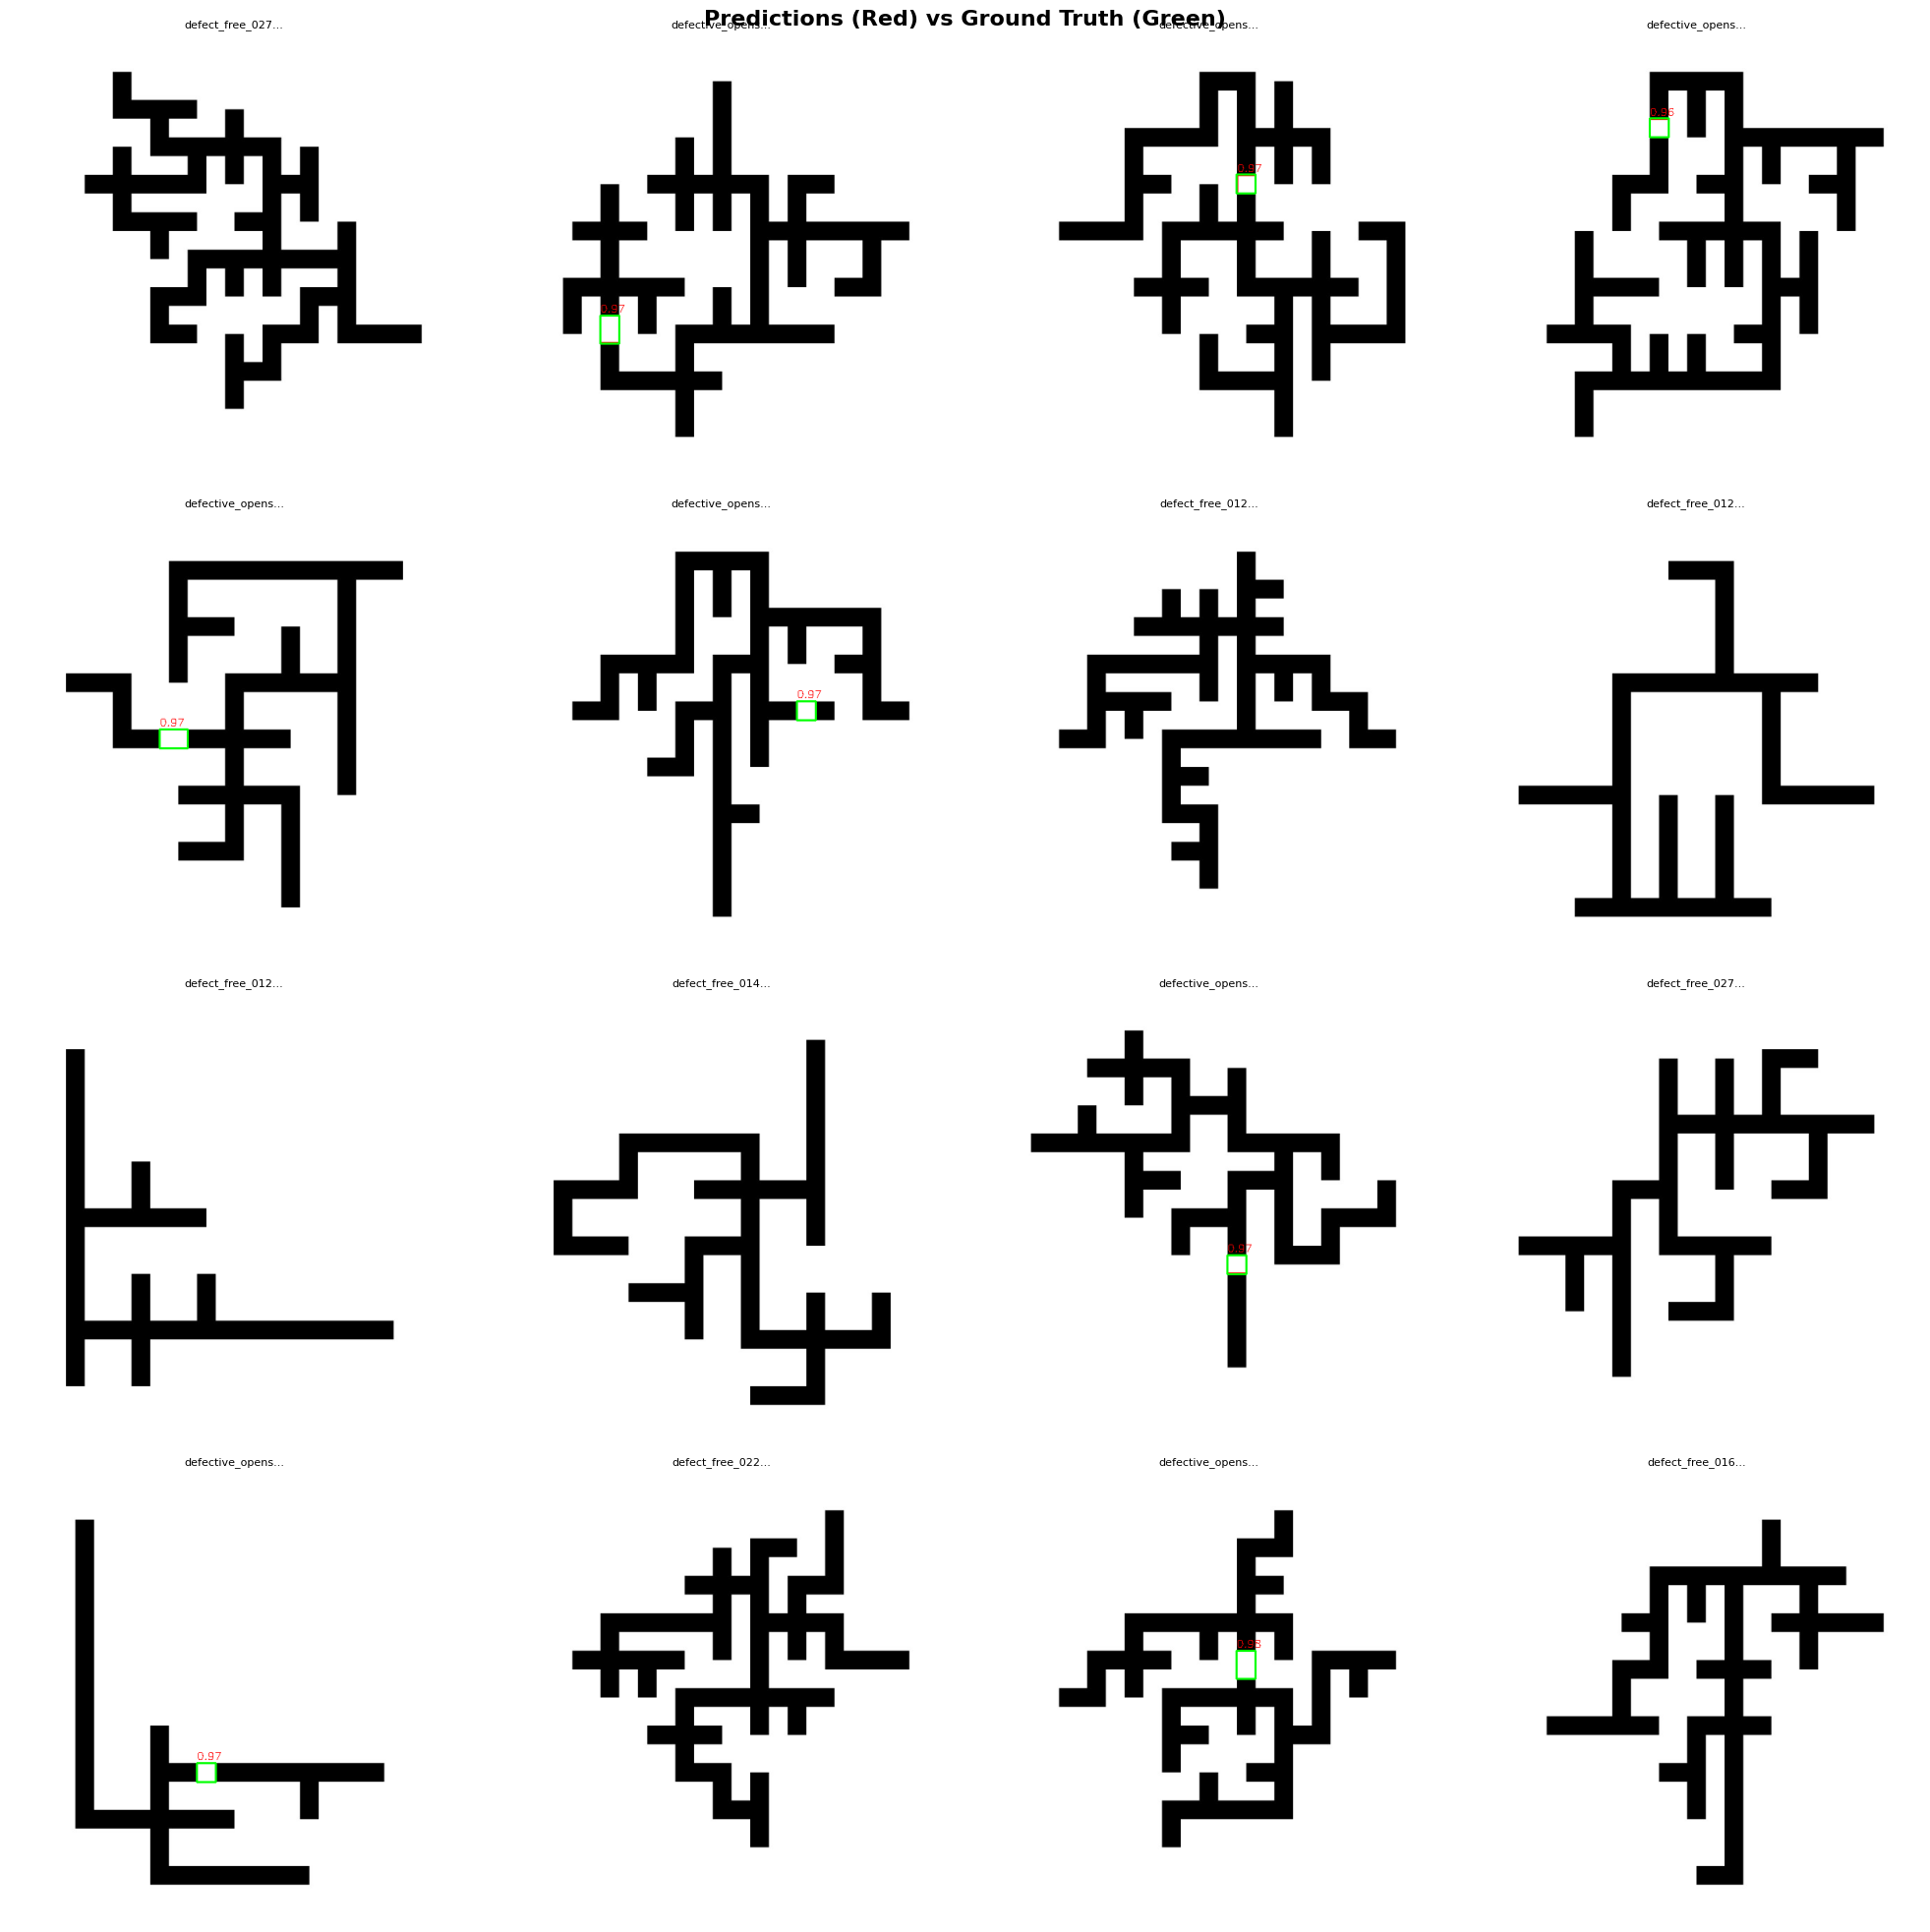


Visualization saved to /content/test_predictions_visualization.png

CONFIDENCE THRESHOLD OPTIMIZATION


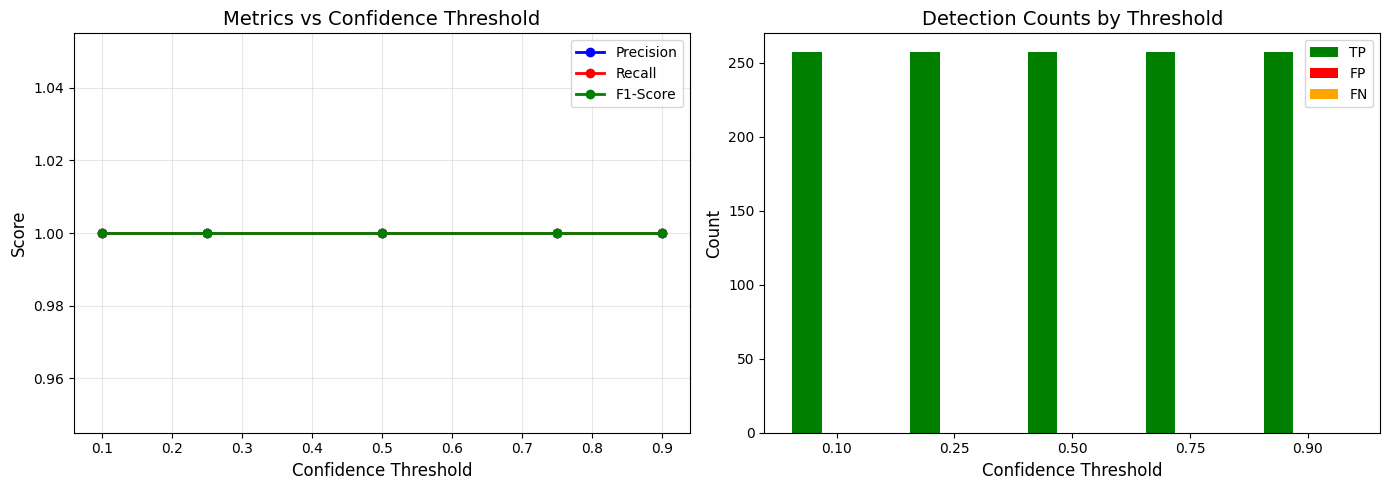


Results by Confidence Threshold:
 threshold  precision  recall  f1
      0.10        1.0     1.0 1.0
      0.25        1.0     1.0 1.0
      0.50        1.0     1.0 1.0
      0.75        1.0     1.0 1.0
      0.90        1.0     1.0 1.0

Optimal threshold (max F1): 0.10
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

INFERENCE SPEED BENCHMARK
Warming up GPU...
Benchmarking on 100 images...


Speed test: 100%|██████████| 100/100 [00:01<00:00, 98.57it/s]



Inference Speed Statistics:
  Mean:   10.08 ms
  Median: 9.91 ms
  Std:    0.81 ms
  Min:    9.21 ms
  Max:    12.72 ms
  FPS:    99.2


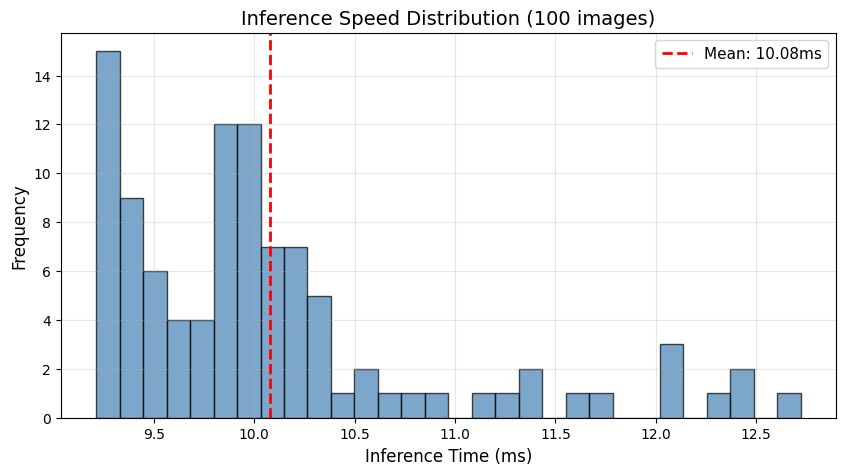


EVALUATION SUMMARY

Overall Performance:
  Test samples:  6333
  Precision:     1.0000
  Recall:        1.0000
  F1-Score:      1.0000
  Accuracy:      1.0000

Localization Quality:
  Mean IoU: 0.9854

Model: /content/training_results/stable_vlsi_20250926_1224/weights/best.pt
Evaluation complete!


In [14]:
# ============================================================================
# SECTION 9: COMPREHENSIVE MODEL EVALUATION
# ============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import cv2
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from tqdm import tqdm
import time

class VLSIModelEvaluator:
    """Comprehensive evaluation of VLSI defect detection model"""

    def __init__(self, model_path, dataset_path):
        self.model_path = Path(model_path)
        self.dataset_path = Path(dataset_path)
        self.model = None
        self.results = {}

    def load_model(self):
        """Load trained YOLO model"""
        if not self.model_path.exists():
            raise FileNotFoundError(f"Model not found: {self.model_path}")

        print(f"Loading model from {self.model_path}")
        self.model = YOLO(str(self.model_path))
        print(f"Model loaded successfully\n")
        return self.model

    def evaluate_on_test_set(self):
        """Run official YOLO evaluation on test set"""
        print("="*60)
        print("OFFICIAL TEST SET EVALUATION")
        print("="*60)

        test_images = self.dataset_path / 'test' / 'images'

        if not test_images.exists():
            print(f"Test set not found at {test_images}")
            return None

        # Run YOLO validation
        results = self.model.val(
            data=str(self.dataset_path / 'dataset.yaml'),
            split='test',
            batch=32,
            conf=0.25,
            iou=0.45,
            verbose=True,
            plots=True
        )

        self.results['test'] = results

        # Extract and display metrics
        print("\nTest Set Performance Metrics:")
        print(f"  mAP@0.5:      {results.box.map50:.4f}")
        print(f"  mAP@0.5:0.95: {results.box.map:.4f}")
        print(f"  Precision:    {results.box.mp:.4f}")
        print(f"  Recall:       {results.box.mr:.4f}")

        return results

    def analyze_full_test_set(self, conf_threshold=0.25):
        """Detailed analysis on entire test set with confusion matrix"""
        print("\n" + "="*60)
        print("DETAILED ANALYSIS - FULL TEST SET")
        print("="*60)

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))
        test_labels = self.dataset_path / 'test' / 'labels'

        if not test_images:
            print("No test images found")
            return None

        print(f"Processing {len(test_images)} test images...")

        # Initialize counters
        tp = fp = fn = tn = 0
        confidence_scores = []
        iou_scores = []

        # Process all images with progress bar
        for img_path in tqdm(test_images, desc="Analyzing"):
            # Load ground truth
            label_path = test_labels / f"{img_path.stem}.txt"
            has_defect_gt = False
            gt_boxes = []

            if label_path.exists():
                with open(label_path, 'r') as f:
                    content = f.read().strip()
                    if content:
                        has_defect_gt = True
                        for line in content.split('\n'):
                            parts = line.strip().split()
                            if len(parts) == 5:
                                _, x, y, w, h = map(float, parts)
                                gt_boxes.append([x, y, w, h])

            # Get model prediction
            results = self.model(str(img_path), conf=conf_threshold, verbose=False)
            has_prediction = results[0].boxes is not None and len(results[0].boxes) > 0

            # Classification logic
            if has_prediction:
                pred_boxes = results[0].boxes.xywhn.cpu().numpy()
                pred_conf = results[0].boxes.conf.cpu().numpy()
                confidence_scores.extend(pred_conf.tolist())

                if has_defect_gt:
                    tp += 1
                    # Calculate IoU for localization quality
                    if gt_boxes:
                        for pred_box in pred_boxes:
                            max_iou = 0
                            for gt_box in gt_boxes:
                                iou = self._calculate_iou(pred_box, gt_box)
                                max_iou = max(max_iou, iou)
                            iou_scores.append(max_iou)
                else:
                    fp += 1
            else:
                if has_defect_gt:
                    fn += 1
                else:
                    tn += 1

        # Calculate metrics
        total = len(test_images)
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1_score = 2 * (precision * recall) / max(precision + recall, 1e-6)
        accuracy = (tp + tn) / total

        # Display results
        print(f"\nConfusion Matrix (Confidence threshold = {conf_threshold}):")
        print(f"  Total samples:    {total}")
        print(f"  True Positives:   {tp}")
        print(f"  False Positives:  {fp}")
        print(f"  False Negatives:  {fn}")
        print(f"  True Negatives:   {tn}")

        print(f"\nPerformance Metrics:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1_score:.4f}")
        print(f"  Accuracy:  {accuracy:.4f}")

        if confidence_scores:
            print(f"\nConfidence Statistics:")
            print(f"  Mean: {np.mean(confidence_scores):.4f}")
            print(f"  Std:  {np.std(confidence_scores):.4f}")
            print(f"  Min:  {np.min(confidence_scores):.4f}")
            print(f"  Max:  {np.max(confidence_scores):.4f}")

        if iou_scores:
            print(f"\nLocalization Quality (IoU):")
            print(f"  Mean: {np.mean(iou_scores):.4f}")
            print(f"  Std:  {np.std(iou_scores):.4f}")
            print(f"  Min:  {np.min(iou_scores):.4f}")
            print(f"  Max:  {np.max(iou_scores):.4f}")

        # Store results
        self.results['full_analysis'] = {
            'total_samples': total,
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'precision': precision,
            'recall': recall,
            'f1': f1_score,
            'accuracy': accuracy,
            'confidence_scores': confidence_scores,
            'iou_scores': iou_scores
        }

        return self.results['full_analysis']

    def _calculate_iou(self, box1, box2):
        """Calculate IoU between two boxes in normalized xywh format"""
        # Convert to corner coordinates
        x1_min = box1[0] - box1[2]/2
        y1_min = box1[1] - box1[3]/2
        x1_max = box1[0] + box1[2]/2
        y1_max = box1[1] + box1[3]/2

        x2_min = box2[0] - box2[2]/2
        y2_min = box2[1] - box2[3]/2
        x2_max = box2[0] + box2[2]/2
        y2_max = box2[1] + box2[3]/2

        # Calculate intersection
        inter_xmin = max(x1_min, x2_min)
        inter_ymin = max(y1_min, y2_min)
        inter_xmax = min(x1_max, x2_max)
        inter_ymax = min(y1_max, y2_max)

        if inter_xmax < inter_xmin or inter_ymax < inter_ymin:
            return 0.0

        inter_area = (inter_xmax - inter_xmin) * (inter_ymax - inter_ymin)

        # Calculate union
        box1_area = box1[2] * box1[3]
        box2_area = box2[2] * box2[3]
        union_area = box1_area + box2_area - inter_area

        return inter_area / max(union_area, 1e-6)

    def visualize_predictions(self, num_samples=16, conf_threshold=0.25):
        """Visualize predictions on random test samples"""
        print("\n" + "="*60)
        print("PREDICTION VISUALIZATION")
        print("="*60)

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))

        if not test_images:
            print("No test images found")
            return

        # Sample random images
        sample_images = np.random.choice(test_images,
                                       min(num_samples, len(test_images)),
                                       replace=False)

        # Create grid
        rows = 4
        cols = 4
        fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
        axes = axes.flatten()

        for idx, img_path in enumerate(sample_images):
            # Load image
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h_img, w_img = img_rgb.shape[:2]

            # Get predictions
            results = self.model(str(img_path), conf=conf_threshold, verbose=False)

            # Draw predictions (red boxes)
            if results[0].boxes is not None:
                for box in results[0].boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()

                    cv2.rectangle(img_rgb,
                                (int(x1), int(y1)),
                                (int(x2), int(y2)),
                                (255, 0, 0), 2)
                    cv2.putText(img_rgb, f'{conf:.2f}',
                              (int(x1), int(y1)-5),
                              cv2.FONT_HERSHEY_SIMPLEX,
                              0.5, (255, 0, 0), 1)

            # Draw ground truth (green boxes)
            label_path = self.dataset_path / 'test' / 'labels' / f"{img_path.stem}.txt"
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f:
                        if line.strip():
                            parts = line.strip().split()
                            if len(parts) == 5:
                                _, x, y, w, h = map(float, parts)
                                x1 = int((x - w/2) * w_img)
                                y1 = int((y - h/2) * h_img)
                                x2 = int((x + w/2) * w_img)
                                y2 = int((y + h/2) * h_img)

                                cv2.rectangle(img_rgb,
                                            (x1, y1), (x2, y2),
                                            (0, 255, 0), 2)

            axes[idx].imshow(img_rgb)
            axes[idx].set_title(f'{img_path.stem[:15]}...', fontsize=8)
            axes[idx].axis('off')

        plt.suptitle('Predictions (Red) vs Ground Truth (Green)',
                    fontsize=16, fontweight='bold')
        plt.tight_layout()

        save_path = '/content/test_predictions_visualization.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\nVisualization saved to {save_path}")

    def confidence_threshold_analysis(self, thresholds=[0.1, 0.25, 0.5, 0.75, 0.9]):
        """Analyze performance across different confidence thresholds"""
        print("\n" + "="*60)
        print("CONFIDENCE THRESHOLD OPTIMIZATION")
        print("="*60)

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))[:500]
        test_labels = self.dataset_path / 'test' / 'labels'

        results_list = []

        for threshold in thresholds:
            tp = fp = fn = tn = 0

            for img_path in tqdm(test_images, desc=f"Threshold {threshold:.2f}", leave=False):
                # Ground truth
                label_path = test_labels / f"{img_path.stem}.txt"
                has_defect_gt = label_path.exists() and label_path.read_text().strip()

                # Prediction
                results = self.model(str(img_path), conf=threshold, verbose=False)
                has_prediction = results[0].boxes is not None and len(results[0].boxes) > 0

                # Count
                if has_prediction and has_defect_gt:
                    tp += 1
                elif has_prediction and not has_defect_gt:
                    fp += 1
                elif not has_prediction and has_defect_gt:
                    fn += 1
                else:
                    tn += 1

            # Metrics
            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)

            results_list.append({
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
            })

        df = pd.DataFrame(results_list)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Metrics plot
        axes[0].plot(df['threshold'], df['precision'], 'bo-', label='Precision', linewidth=2)
        axes[0].plot(df['threshold'], df['recall'], 'ro-', label='Recall', linewidth=2)
        axes[0].plot(df['threshold'], df['f1'], 'go-', label='F1-Score', linewidth=2)
        axes[0].set_xlabel('Confidence Threshold', fontsize=12)
        axes[0].set_ylabel('Score', fontsize=12)
        axes[0].set_title('Metrics vs Confidence Threshold', fontsize=14)
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)

        # Counts plot
        x = np.arange(len(df))
        width = 0.25
        axes[1].bar(x - width, df['tp'], width, label='TP', color='green')
        axes[1].bar(x, df['fp'], width, label='FP', color='red')
        axes[1].bar(x + width, df['fn'], width, label='FN', color='orange')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels([f'{t:.2f}' for t in df['threshold']])
        axes[1].set_xlabel('Confidence Threshold', fontsize=12)
        axes[1].set_ylabel('Count', fontsize=12)
        axes[1].set_title('Detection Counts by Threshold', fontsize=14)
        axes[1].legend(fontsize=10)

        plt.tight_layout()
        plt.savefig('/content/threshold_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Print results
        print("\nResults by Confidence Threshold:")
        print(df[['threshold', 'precision', 'recall', 'f1']].to_string(index=False))

        # Optimal threshold
        optimal_idx = df['f1'].idxmax()
        print(f"\nOptimal threshold (max F1): {df.loc[optimal_idx, 'threshold']:.2f}")
        print(f"  Precision: {df.loc[optimal_idx, 'precision']:.4f}")
        print(f"  Recall:    {df.loc[optimal_idx, 'recall']:.4f}")
        print(f"  F1-Score:  {df.loc[optimal_idx, 'f1']:.4f}")

        return df

    def inference_speed_benchmark(self, num_images=100):
        """Benchmark inference speed"""
        print("\n" + "="*60)
        print("INFERENCE SPEED BENCHMARK")
        print("="*60)

        test_images = list((self.dataset_path / 'test' / 'images').glob('*.jpg'))[:num_images]

        if not test_images:
            print("No test images found")
            return None

        # Warmup
        print(f"Warming up GPU...")
        for _ in range(5):
            _ = self.model(str(test_images[0]), verbose=False)

        # Benchmark
        print(f"Benchmarking on {num_images} images...")
        times = []

        for img_path in tqdm(test_images, desc="Speed test"):
            start = time.time()
            _ = self.model(str(img_path), verbose=False)
            times.append(time.time() - start)

        times = np.array(times) * 1000  # Convert to ms

        print(f"\nInference Speed Statistics:")
        print(f"  Mean:   {np.mean(times):.2f} ms")
        print(f"  Median: {np.median(times):.2f} ms")
        print(f"  Std:    {np.std(times):.2f} ms")
        print(f"  Min:    {np.min(times):.2f} ms")
        print(f"  Max:    {np.max(times):.2f} ms")
        print(f"  FPS:    {1000/np.mean(times):.1f}")

        # Plot distribution
        plt.figure(figsize=(10, 5))
        plt.hist(times, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        plt.axvline(np.mean(times), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(times):.2f}ms')
        plt.xlabel('Inference Time (ms)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title(f'Inference Speed Distribution ({num_images} images)', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.savefig('/content/inference_speed.png', dpi=150, bbox_inches='tight')
        plt.show()

        return times


# ============================================================================
# EXECUTE EVALUATION PIPELINE
# ============================================================================

print("="*60)
print("VLSI DEFECT DETECTION - MODEL EVALUATION")
print("="*60)

# Auto-find the trained model
model_path = None
search_paths = [
    '/content/training_results/balanced_vlsi_local_20250906_0943/weights/best.pt',
    '/content/stable_best_vlsi_model.pt',
    '/content/training_results/stable_best_model.pt',
]

# Check predefined paths first
for path in search_paths:
    if Path(path).exists():
        model_path = path
        break

# If not found, search training_results directory
if not model_path:
    training_dir = Path('/content/training_results')
    if training_dir.exists():
        models = list(training_dir.rglob('weights/best.pt'))
        if models:
            # Use most recent
            model_path = str(max(models, key=lambda p: p.stat().st_mtime))

if model_path:
    print(f"Found model: {model_path}\n")

    # Initialize evaluator
    evaluator = VLSIModelEvaluator(
        model_path=model_path,
        dataset_path='/content/yolo_dataset_local'
    )

    try:
        # 1. Load model
        evaluator.load_model()

        # 2. Official test set evaluation
        test_results = evaluator.evaluate_on_test_set()

        # 3. Detailed analysis on full test set
        analysis_results = evaluator.analyze_full_test_set(conf_threshold=0.25)

        # 4. Visualize predictions
        evaluator.visualize_predictions(num_samples=16, conf_threshold=0.25)

        # 5. Confidence threshold optimization
        threshold_df = evaluator.confidence_threshold_analysis()

        # 6. Inference speed benchmark
        speed_times = evaluator.inference_speed_benchmark(num_images=100)

        # 7. Final summary
        print("\n" + "="*60)
        print("EVALUATION SUMMARY")
        print("="*60)

        if 'full_analysis' in evaluator.results:
            res = evaluator.results['full_analysis']
            print(f"\nOverall Performance:")
            print(f"  Test samples:  {res['total_samples']}")
            print(f"  Precision:     {res['precision']:.4f}")
            print(f"  Recall:        {res['recall']:.4f}")
            print(f"  F1-Score:      {res['f1']:.4f}")
            print(f"  Accuracy:      {res['accuracy']:.4f}")

            if res['iou_scores']:
                print(f"\nLocalization Quality:")
                print(f"  Mean IoU: {np.mean(res['iou_scores']):.4f}")

            print(f"\nModel: {model_path}")
            print(f"Evaluation complete!")

    except Exception as e:
        print(f"\nEvaluation failed: {e}")
        import traceback
        traceback.print_exc()

else:
    print("ERROR: No trained model found!")
    print("\nSearched locations:")
    for path in search_paths:
        print(f"  - {path}")
    print("\nPlease verify the model path or re-run training (Section 8)")